In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_predictions, get_improvement
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colormaps
cmap = colormaps["viridis"]
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 25,
    "g": saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 200,
    "monitor_convergence": False,
}

In [4]:
# results for:
# n_x = 1000
# n_train = 10
# n_test = 25
# num_iter = 100
# clip = True
rank_all = [10, 20, 30, 50]
sigma_all = [0.03942593, 0.04462963, 0.01472222, 0.00856173]
c_all = [4.38271605, 2.65432099, 1.54320988, 1.66666667]
improvements_all = [ -72.8255, -59.2829, -49.7318, -54.6926]
# results for:
# n_x = 1000
# n_train = 10
# n_test = 10
# num_iter1 = 100
# num_iter2 = 1001
# clip = True
# rank = [10, 20, 30, 50]
# sigma = [0.08658411693500023, 0.06753569193117442, 0.04260935916899724, 0.01348455548077379]
# c = [2.147755288610398, 0.5273285959317914, 0.3269542485762022, 0.6772697328198871]
# improvements = [-82.8685,-72.4666, -64.0511, -60.1164]


In [5]:
# Results from SLSQP for rank 10, 20, 30, 50
# 100, 0.03646128, 4.99222927, 0.19080839, 0.17958300, 0.05171203, -72.8985
# 100, 0.04492240, 2.55252688, 0.12313309, 0.16628224, 0.05013127, -59.2869
# 100, 0.02332058, 0.88578413, 0.09915827, 0.11522427, 0.05024713, -49.3263
# 100, 0.00828402, 1.70336367, 0.07731714, 0.07488915, 0.03507394, -54.6363

# Results from DIRECT for rank 10, 20, 30, 50
# 100, 0.03942593, 4.38271605, 0.19080839, 0.18189029, 0.05185121, -72.8255
# 100, 0.04462963, 2.65432099, 0.12313309, 0.16580169, 0.05013620, -59.2829
# 100, 0.01472222, 1.54320988, 0.09915827, 0.09796930, 0.04984510, -49.7318
# 100, 0.00856173, 1.66666667, 0.07731714, 0.07542985, 0.03503037, -54.6926

# results saw tooth
# 100, 0.07938889, 2.16049383, 0.13111639, 0.12975659, 0.06033007, -53.9874
# 100, 0.08749383, 2.03703704, 0.08979783, 0.12978039, 0.06061652, -32.4967
# 100, 0.01472222, 1.17283951, 0.07392332, 0.07225932, 0.04773219, -35.4301
# 100, 0.00916667, 1.04938272, 0.05567498, 0.05495678, 0.03668844, -34.1025
sigma_all = [0.07938889, 0.08749383, 0.01472222, 0.00916667]
c_all = [2.16049383, 2.03703704, 1.17283951, 1.04938272]

In [6]:
case["num_iter"] = 100
for i in range(4):
    case["n_train"] = rank_all[i]
    case["sigma"] = sigma_all[i]
    case["c"] = c_all[i]
    
    parameters = optimize_hyperparameters(case)

    print("- - - - - - - - - - - - - - - - - - - - - - - - - ")
    case["n_train"] = rank_all[i]
    case["sigma"] = sigma_all[i]
    case["c"] = c_all[i]
    target_function(case)
    print("- - - - - - - - - - - - - - - - - - - - - - - - - ")
    case["sigma"] = parameters[0]
    case["c"] = parameters[1]
    target_function(case)
    print("- - - - - - - - - - - - - - - - - - - - - - - - - ")
    sigma_all[i] = parameters[0]
    c_all[i] = parameters[1]
print(sigma_all)
print(c_all)

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


100, 0.12550000, 0.12500000, 0.13111639, 0.13777389, 0.10688508, -18.4808
100, 0.20850000, 0.12500000, 0.13111639, 0.14425629, 0.14186669, 8.1991
100, 0.04250000, 0.12500000, 0.13111639, 0.11850823, 0.07247036, -44.7282
100, 0.12550000, 0.20833333, 0.13111639, 0.13777389, 0.07249118, -44.7123
100, 0.12550000, 0.04166667, 0.13111639, 0.13777389, 0.13685894, 4.3797
100, 0.04250000, 0.20833333, 0.13111639, 0.11850823, 0.06170248, -52.9407
100, 0.04250000, 0.04166667, 0.13111639, 0.11850823, 0.11734819, -10.5007
100, 0.20850000, 0.20833333, 0.13111639, 0.14425629, 0.12049907, -8.0976
100, 0.20850000, 0.04166667, 0.13111639, 0.14425629, 0.14403959, 9.8563
100, 0.07016667, 0.20833333, 0.13111639, 0.12737034, 0.06286058, -52.0574
100, 0.01483333, 0.20833333, 0.13111639, 0.11700851, 0.08442413, -35.6113
100, 0.04250000, 0.23611111, 0.13111639, 0.11850823, 0.06548358, -50.0569
100, 0.04250000, 0.18055556, 0.13111639, 0.11850823, 0.06027820, -54.0270
100, 0.07016667, 0.18055556, 0.13111639, 0.12

In [7]:
n_sigmaDs = 251
esROMs = np.empty((case["n_test"], case["num_iter"], n_sigmaDs, 4))  # i, m, n, case

for case_nr, _rank, _sigma, _c in zip((0, 1, 2, 3), rank_all, sigma_all, c_all):
    print("generate snapshots")
    print("build ROM and predict")
    n_train = _rank
    case["n_train"] = _rank
    case["rank"] = _rank
    case["sigma"] = _sigma
    case["c"] = _c
    shape = case["shape"]

    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, _ = get_predictions(my_sROM, mu_test, **case)

    print("we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot")
    print("SigmaD is varied and we see what happens with the error with the number of iterations in RL")
    #deconvolved = np.ones((*data.shape, num_iter))
    sigmaDs = np.linspace(0, 5 / (_rank * 2), n_sigmaDs)
    for n, sigmaD in enumerate(sigmaDs):
        print(n, sigmaD, end=",\t")
        for i in range(len(mu_test)):
            deconvolved = richardson_lucy(
                x,
                X_test_sROM[i].reshape(shape),
                sigmaD,
                case["num_iter"],
                monitor_convergence=True,
            ).reshape((case["n_x"], case["num_iter"]))

            esROMs[i, :, n, case_nr] = L2_error_rw(deconvolved, X_test[i, :, None], axis=0)

np.save("./esROMs.npy", esROMs)

generate snapshots
build ROM and predict
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.0,	1 0.001,	2 0.002,	3 0.003,	4 0.004,	5 0.005,	6 0.006,	7 0.007,	8 0.008,	9 0.009000000000000001,	10 0.01,	11 0.011,	12 0.012,	13 0.013000000000000001,	14 0.014,	15 0.015,	16 0.016,	17 0.017,	18 0.018000000000000002,	19 0.019,	20 0.02,	21 0.021,	22 0.022,	23 0.023,	24 0.024,	25 0.025,	26 0.026000000000000002,	27 0.027,	28 0.028,	29 0.029,	30 0.03,	31 0.031,	32 0.032,	33 0.033,	34 0.034,	35 0.035,	36 0.036000000000000004,	37 0.037,	38 0.038,	39 0.039,	40 0.04,	41 0.041,	42 0.042,	43 0.043000000000000003,	44 0.044,	45 0.045,	46 0.046,	47 0.047,	48 0.048,	49 0.049,	50 0.05,	51 0.051000000000000004,	52 0.052000000000000005,	53 0.053,	54 0.054,	55 0.055,	56 0.056,	57 0.057,	58 0.058,	59 0.059000000000000004,	60 0.06,	61 0.061,	62 0.062,	63 0.063,	64 0

generate snapshots
build ROM and predict


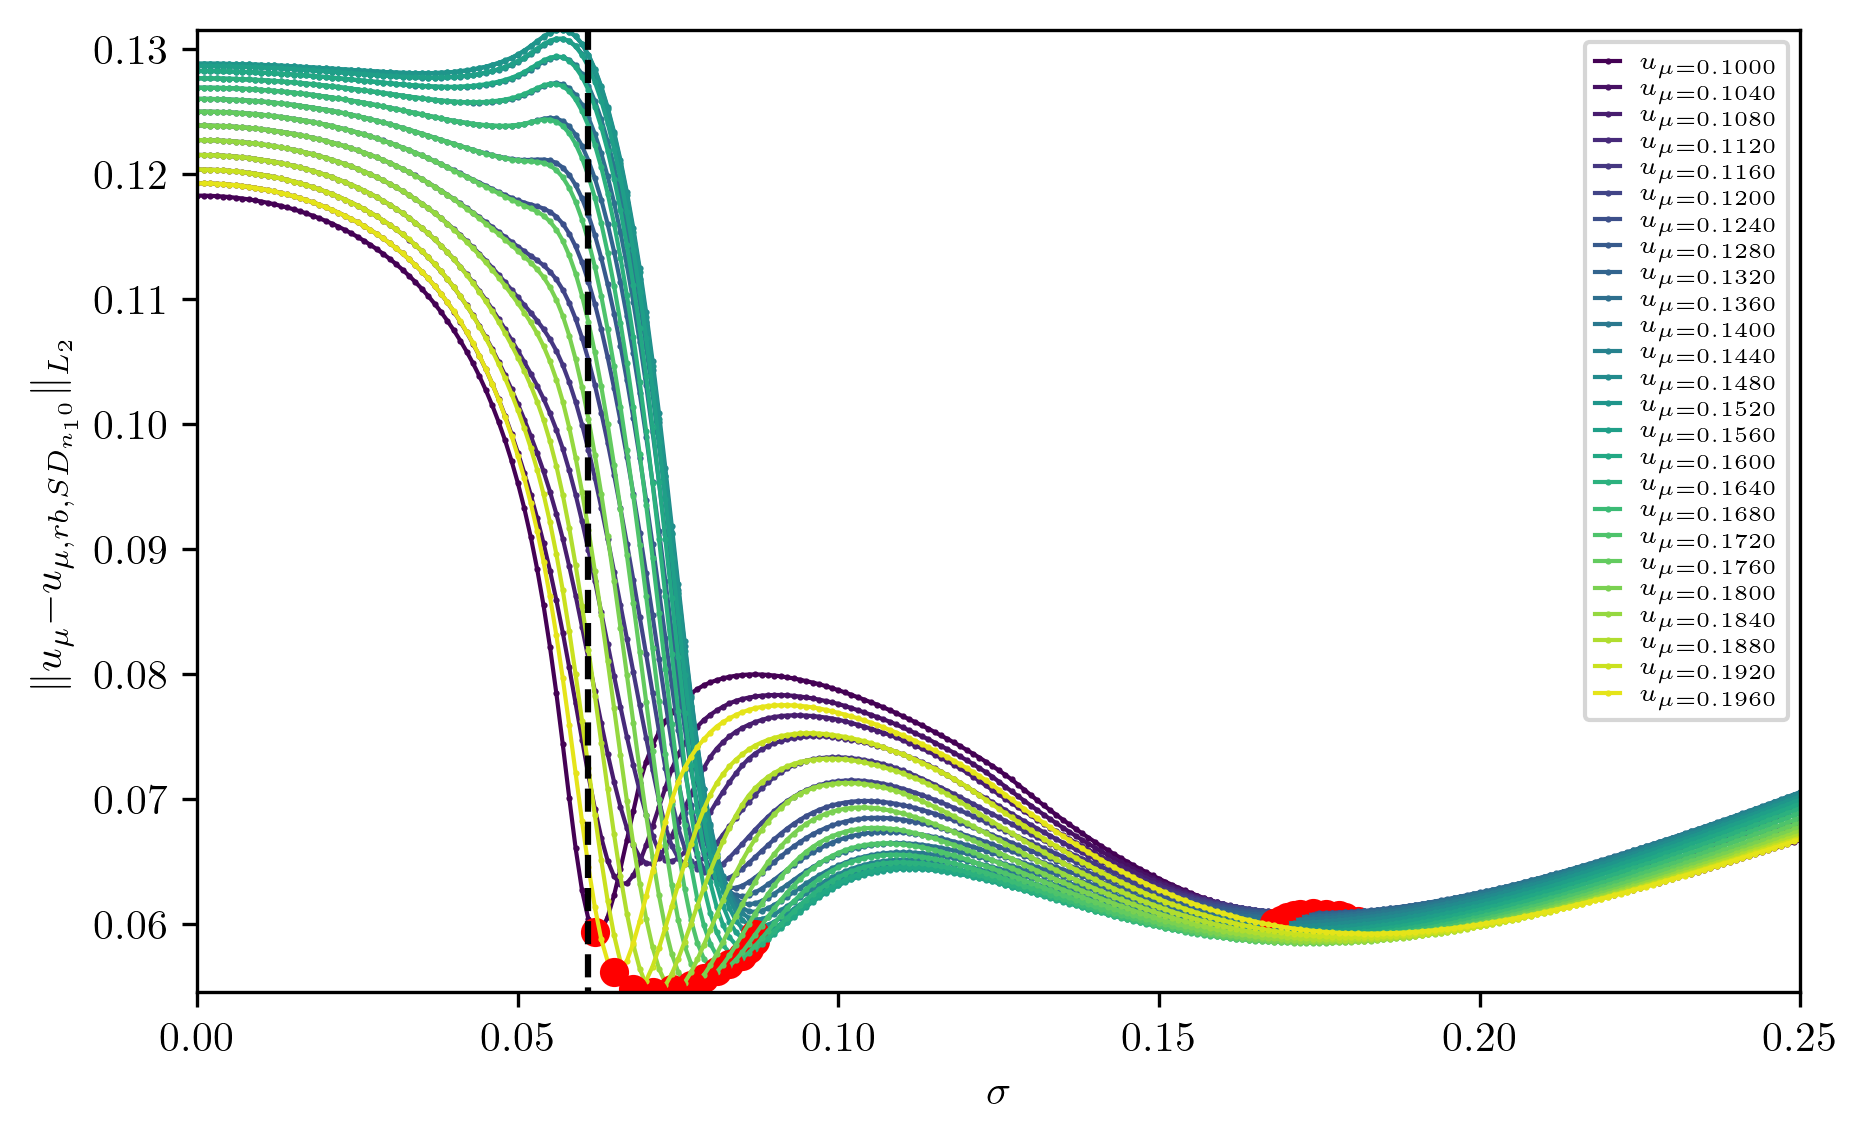

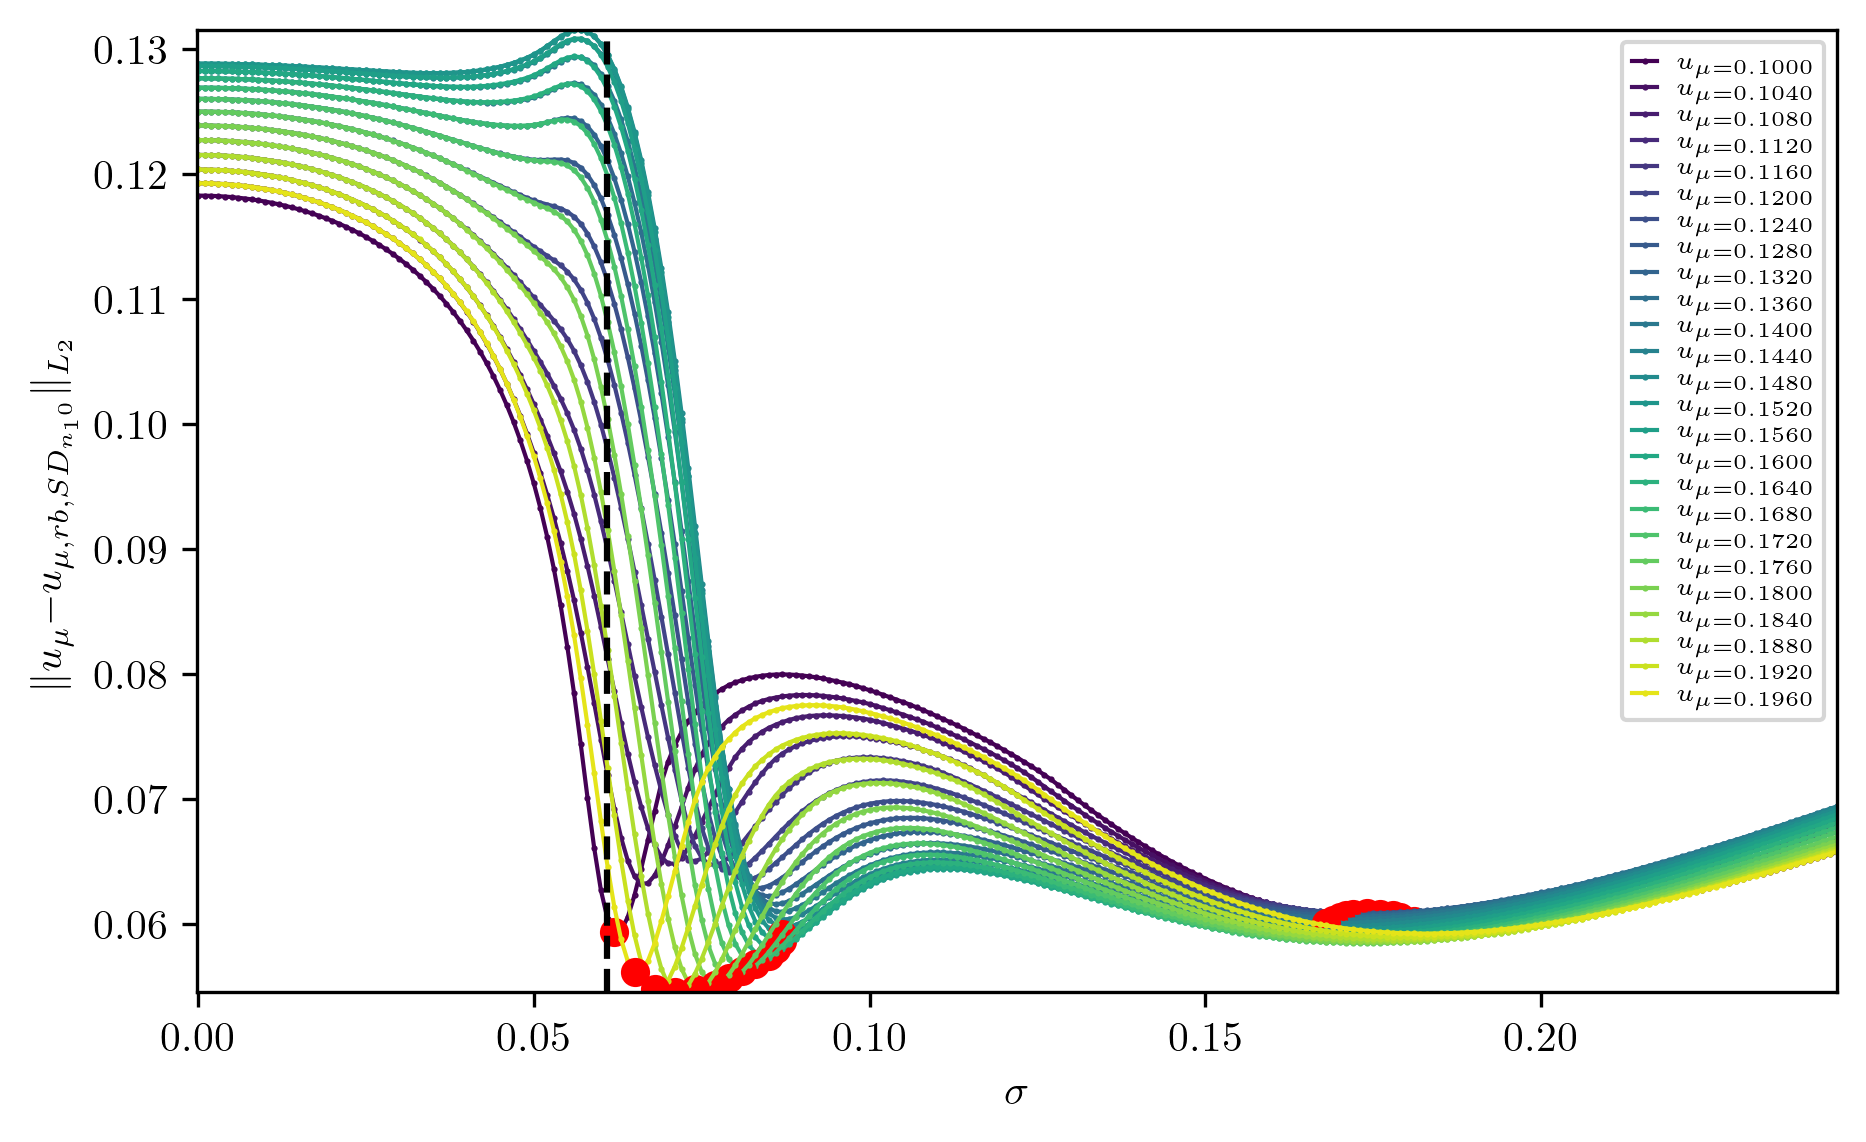

generate snapshots
build ROM and predict


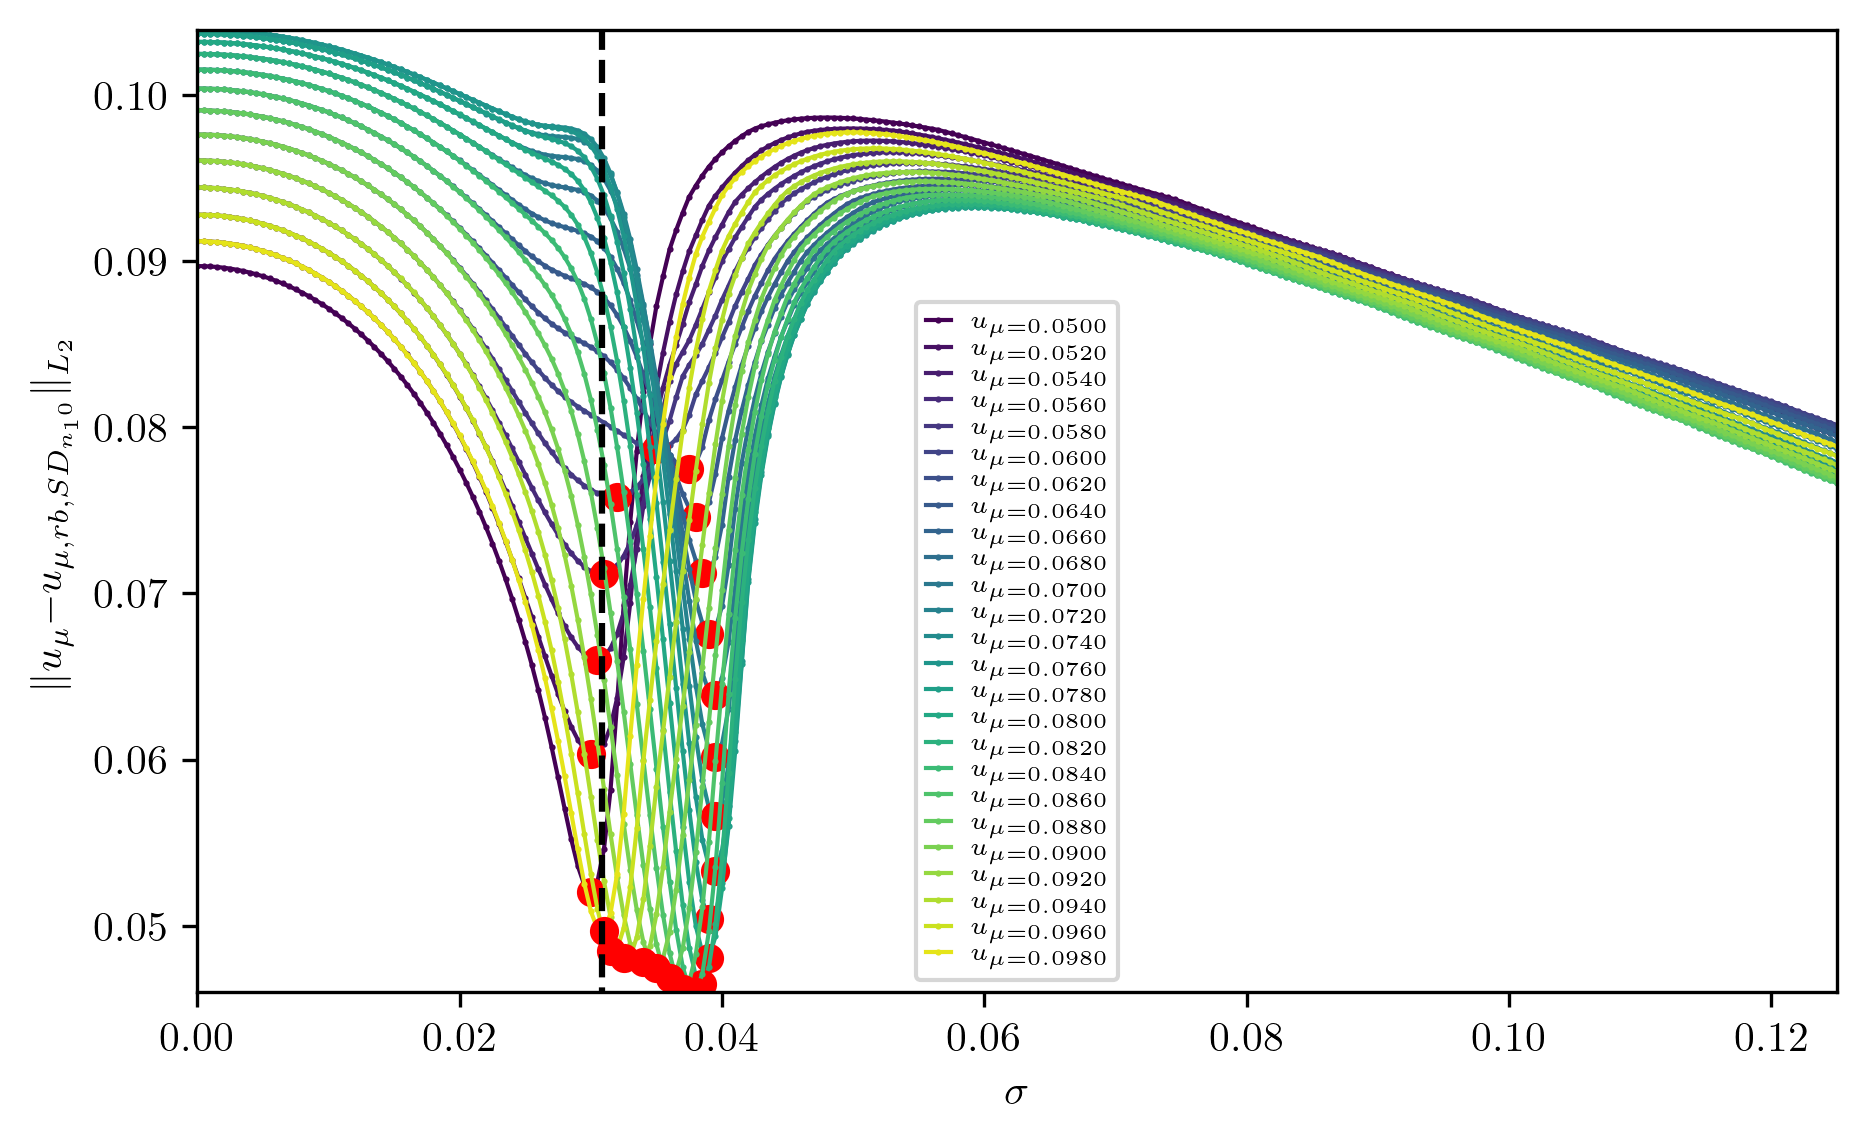

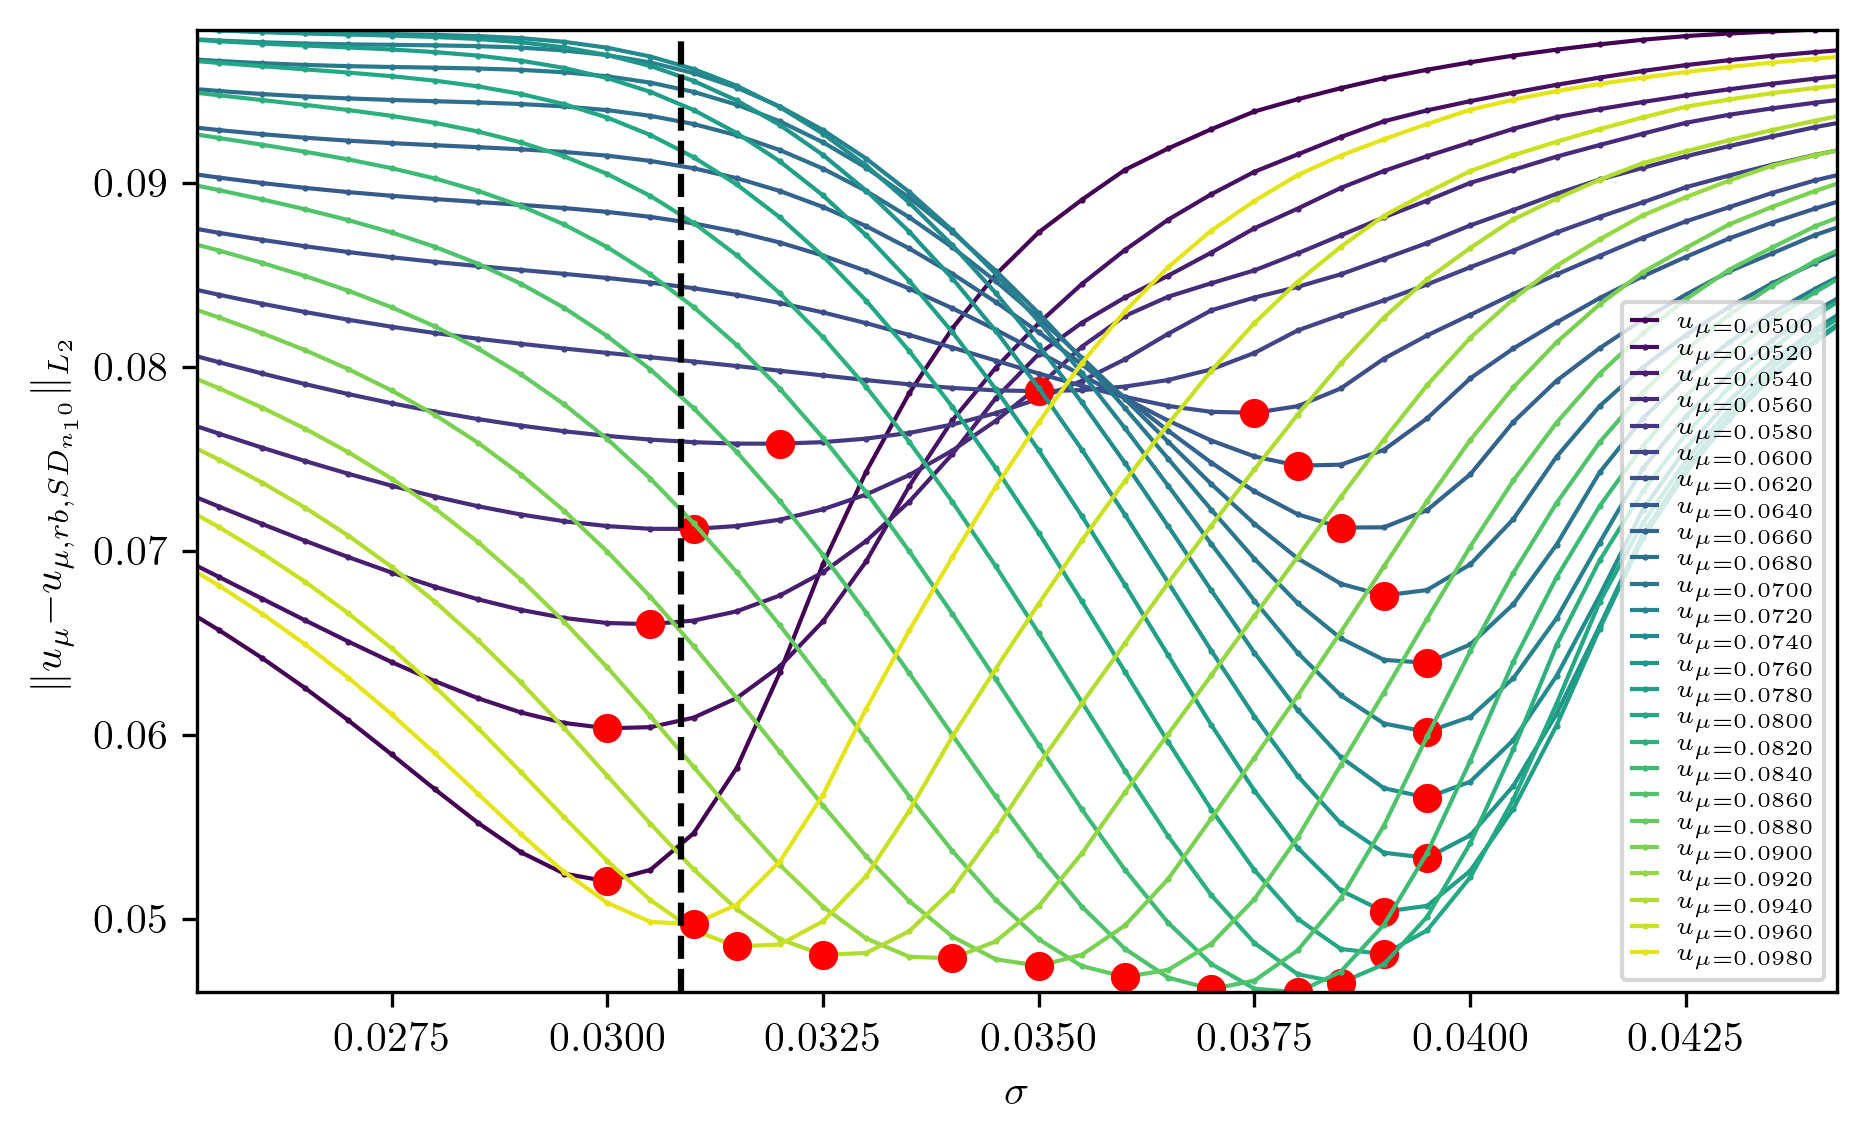

generate snapshots
build ROM and predict


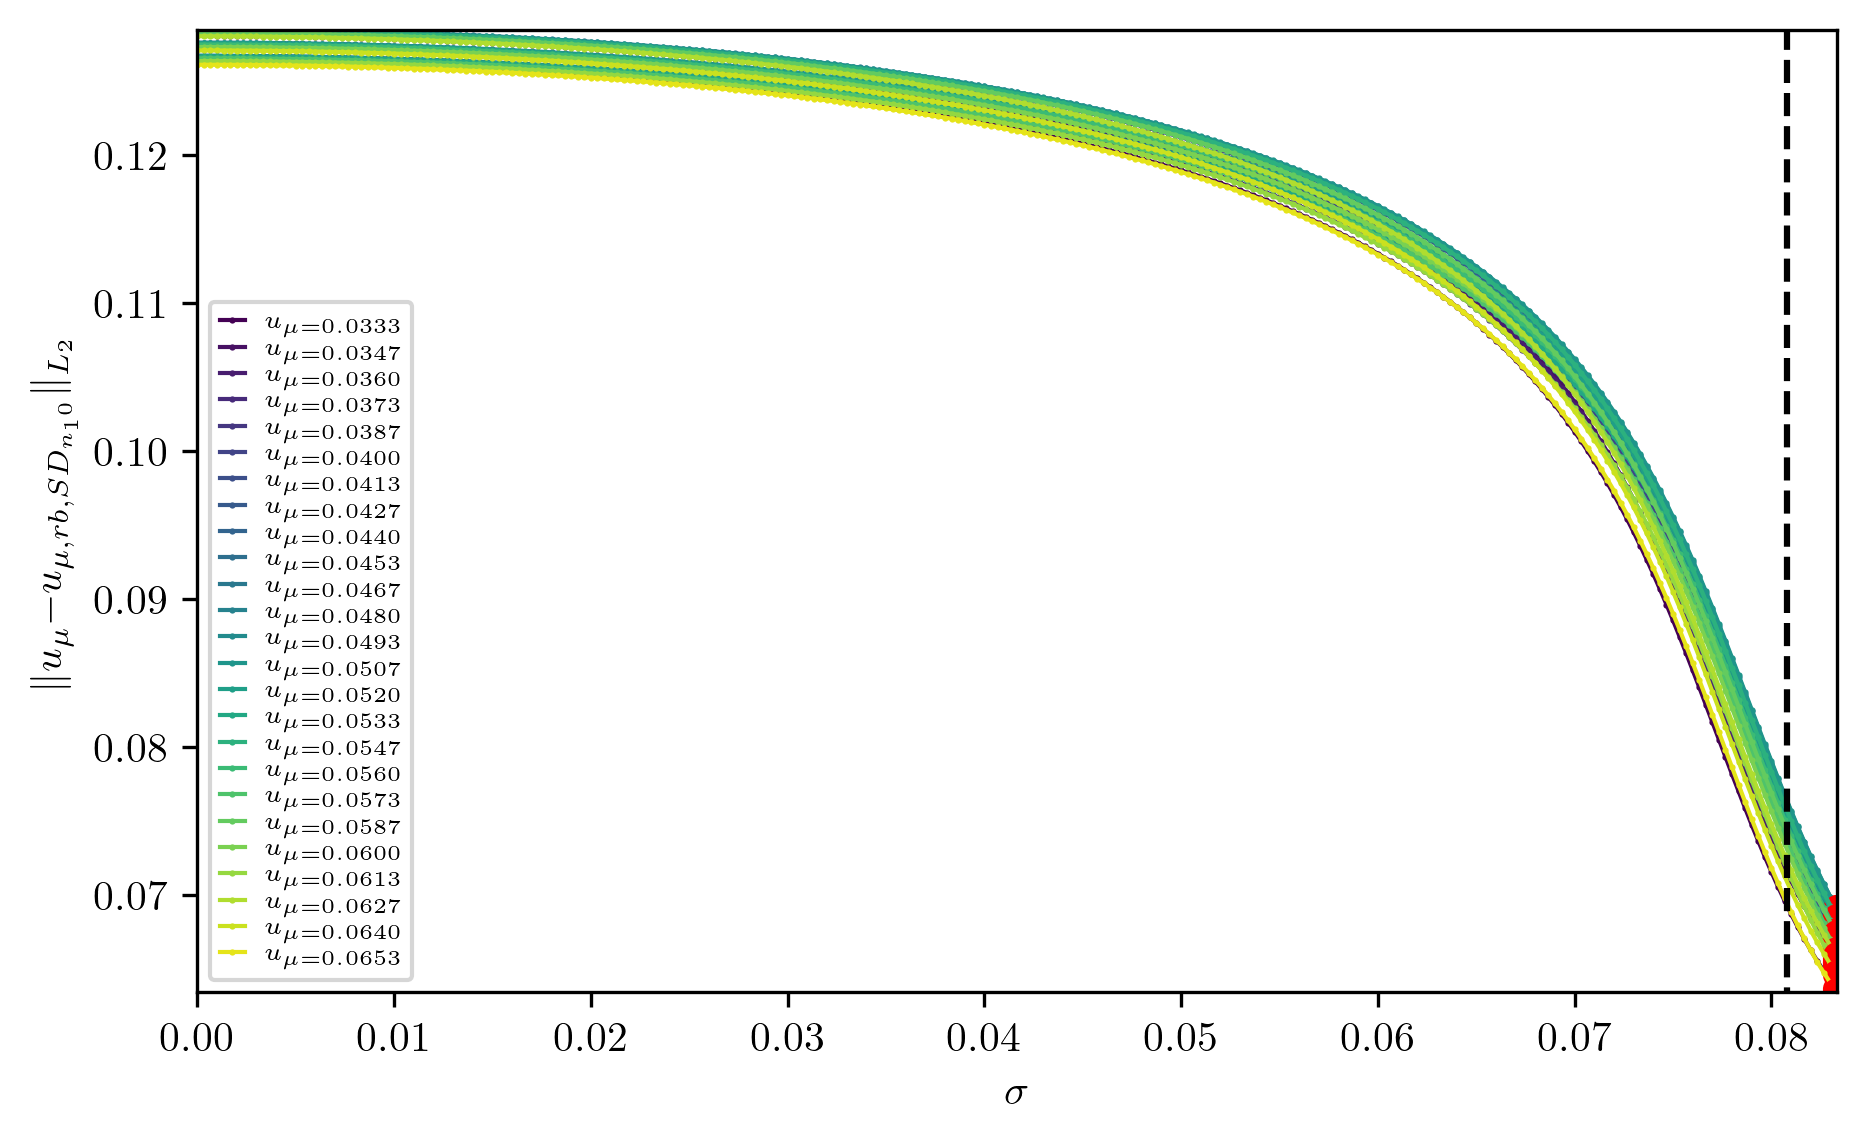

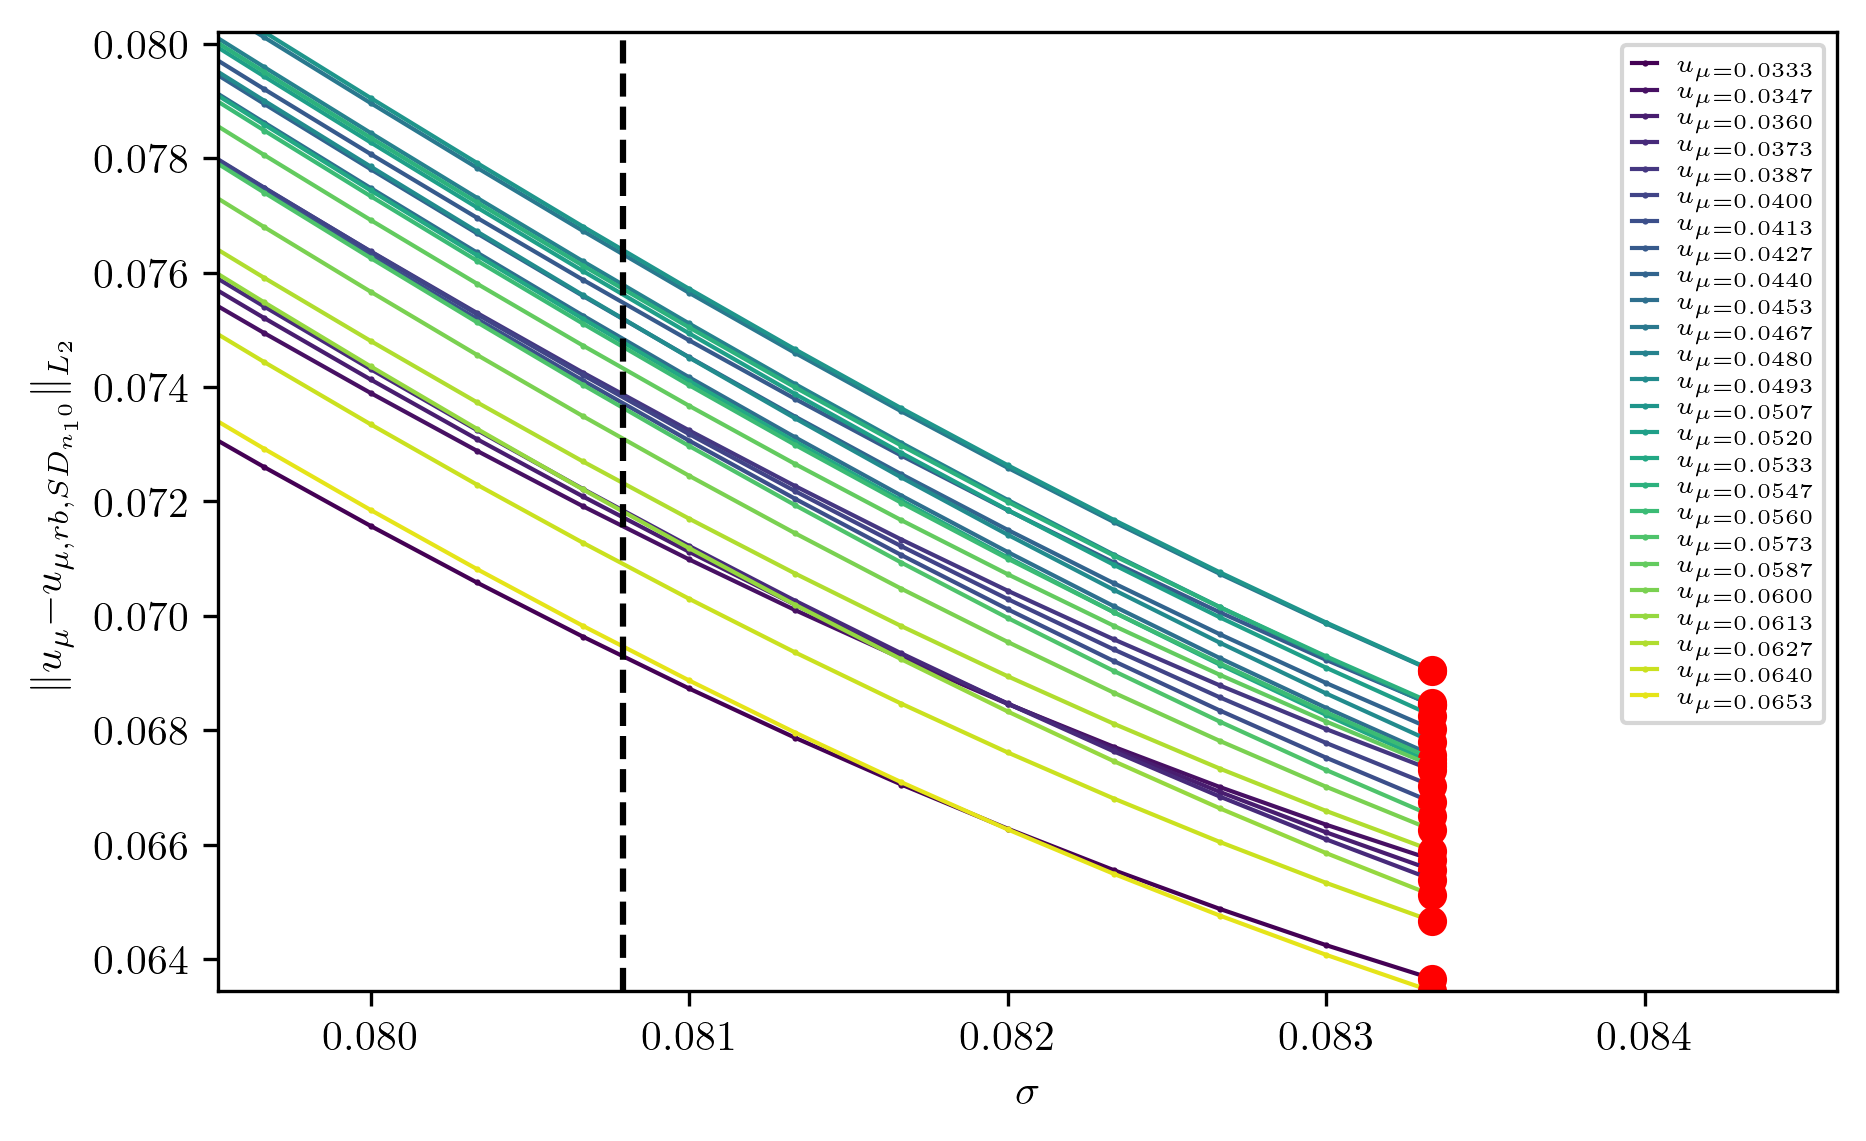

generate snapshots
build ROM and predict


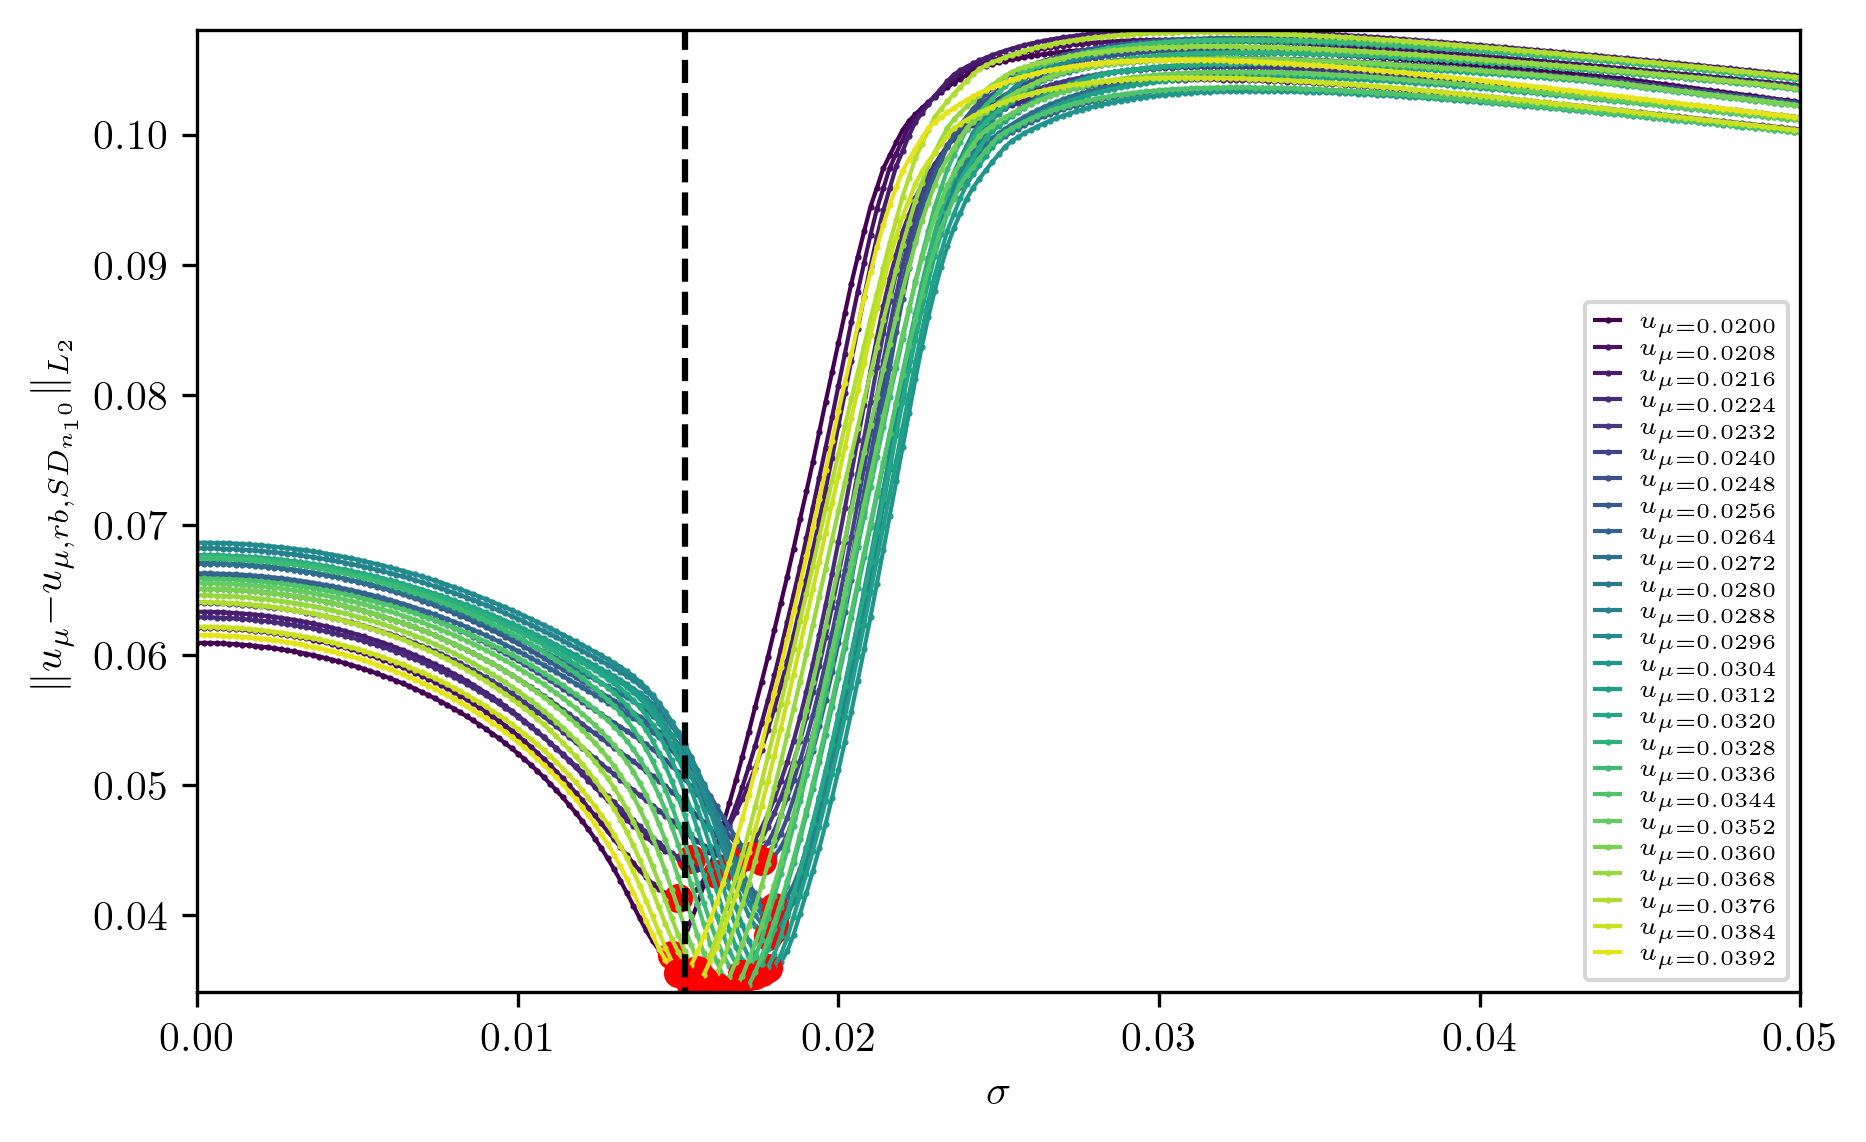

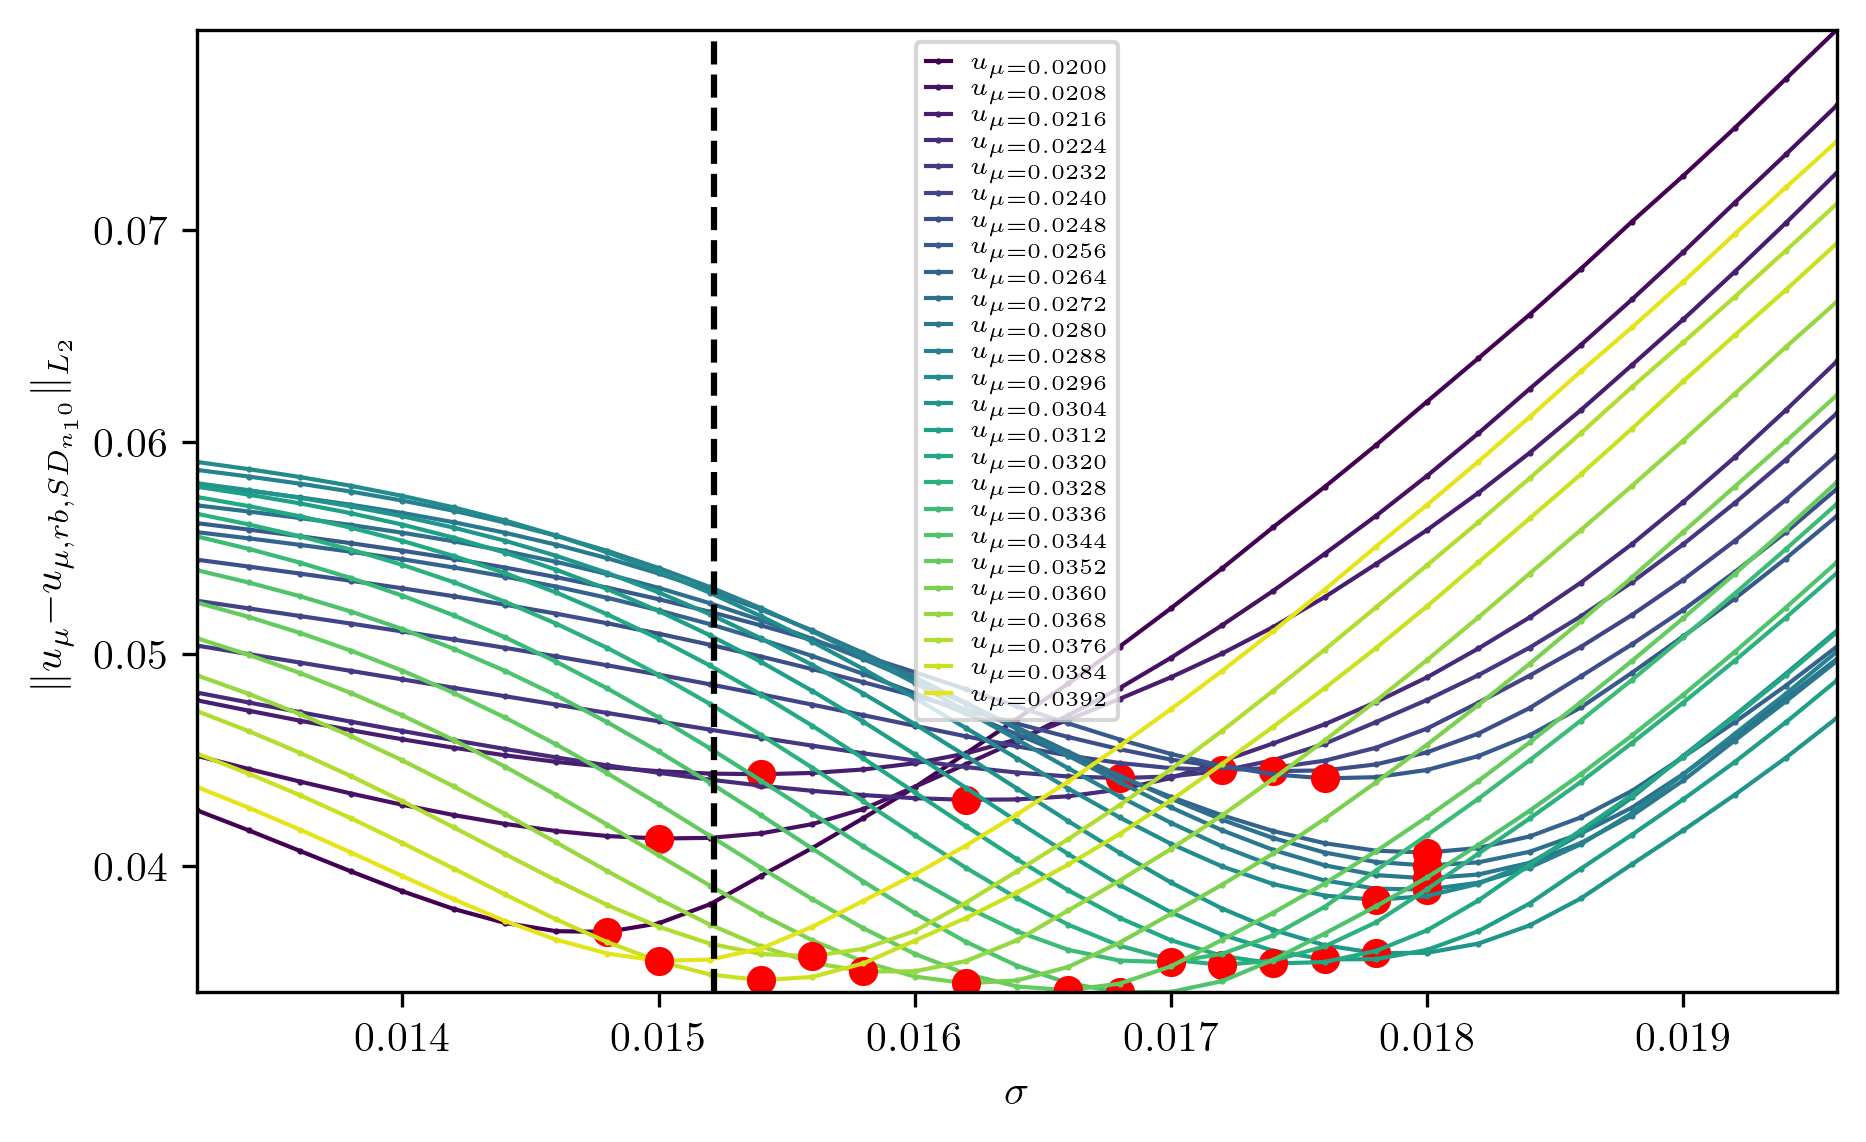

In [8]:
esROMs = np.load("./esROMs.npy")

for case_nr, _rank, _sigma, _c in zip((0, 1, 2, 3), rank_all, sigma_all, c_all):
    print("generate snapshots")
    print("build ROM and predict")
    n_train = _rank
    case["n_train"] = _rank
    case["rank"] = _rank
    case["sigma"] = _sigma
    case["c"] = _c
    shape = case["shape"]

    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, _ = get_predictions(my_sROM, mu_test, **case)


    sigmaDs = np.linspace(0, 5 / (_rank * 2), n_sigmaDs)

    fig, ax = plt.subplots(figsize=(plot_width_in*2, plot_width_in*2/1.61803398875))
    for i in range(0, case["n_test"], 1):
        plt.plot(sigmaDs, esROMs[i, -1, :, case_nr], marker=".", ms=1, lw=1,
                 color=cmap(i/case["n_test"]), label=r"$u_{\mu="+"{:.4f}".format(mu_test[i, 0])+"}$")
        i_min_error = np.argmin(esROMs[i, -1, :, case_nr])
        plt.plot(sigmaDs[i_min_error], esROMs[i, -1, i_min_error, case_nr], "ro")
    #plt.plot(sigmaDs, np.mean(esROMs[:, -1, :, case_nr], axis=0), "k--")
    plt.plot((_sigma, _sigma), (0, 1), "k--")
    plt.legend()
    plt.xlim(0, np.max(sigmaDs))
    plt.ylim(np.min(esROMs[:, -1, :, case_nr]), np.max(esROMs[:, -1, :, case_nr]))
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_10}}}\|_{L_2}$")
    plt.xlabel(r"$\sigma$")
    plt.show()


    smin, smax = _sigma, _sigma
    for i in range(0, case["n_test"], 1):
        i_min_error = np.argmin(esROMs[i, -1, :, case_nr])
        if sigmaDs[i_min_error] < smin:
            smin = sigmaDs[i_min_error]
        if sigmaDs[i_min_error] > smax:
            smax = sigmaDs[i_min_error]
    srange = smax-smin
    smin, smax = smin-srange*.5, smax+srange*.5
    mask = (smin<sigmaDs) & (sigmaDs< smax)
    ymin, ymax = np.min(esROMs[:, -1, mask, case_nr]), np.max(esROMs[:, -1, mask, case_nr])
    
    fig, ax = plt.subplots(figsize=(plot_width_in*2, plot_width_in*2/1.61803398875))
    for i in range(0, case["n_test"], 1):
        plt.plot(sigmaDs, esROMs[i, -1, :, case_nr], marker=".", ms=1, lw=1,
                 color=cmap(i/case["n_test"]), label=r"$u_{\mu="+"{:.4f}".format(mu_test[i, 0])+"}$")
        i_min_error = np.argmin(esROMs[i, -1, :, case_nr])
        plt.plot(sigmaDs[i_min_error], esROMs[i, -1, i_min_error, case_nr], "ro")
    #plt.plot(sigmaDs, np.mean(esROMs[:, -1, :, case_nr], axis=0), "k--")
    plt.plot((_sigma, _sigma), (ymin, ymax), "k--")
    plt.legend()
    plt.xlim(smin, smax)
    plt.ylim(ymin, ymax)
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_10}}}\|_{L_2}$")
    plt.xlabel(r"$\sigma$")
    plt.show()

generate snapshots
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.06094444444444445
1 0.030851851851851856
2 0.08079218106995883
3 0.015216049382716052
how does the error converge?


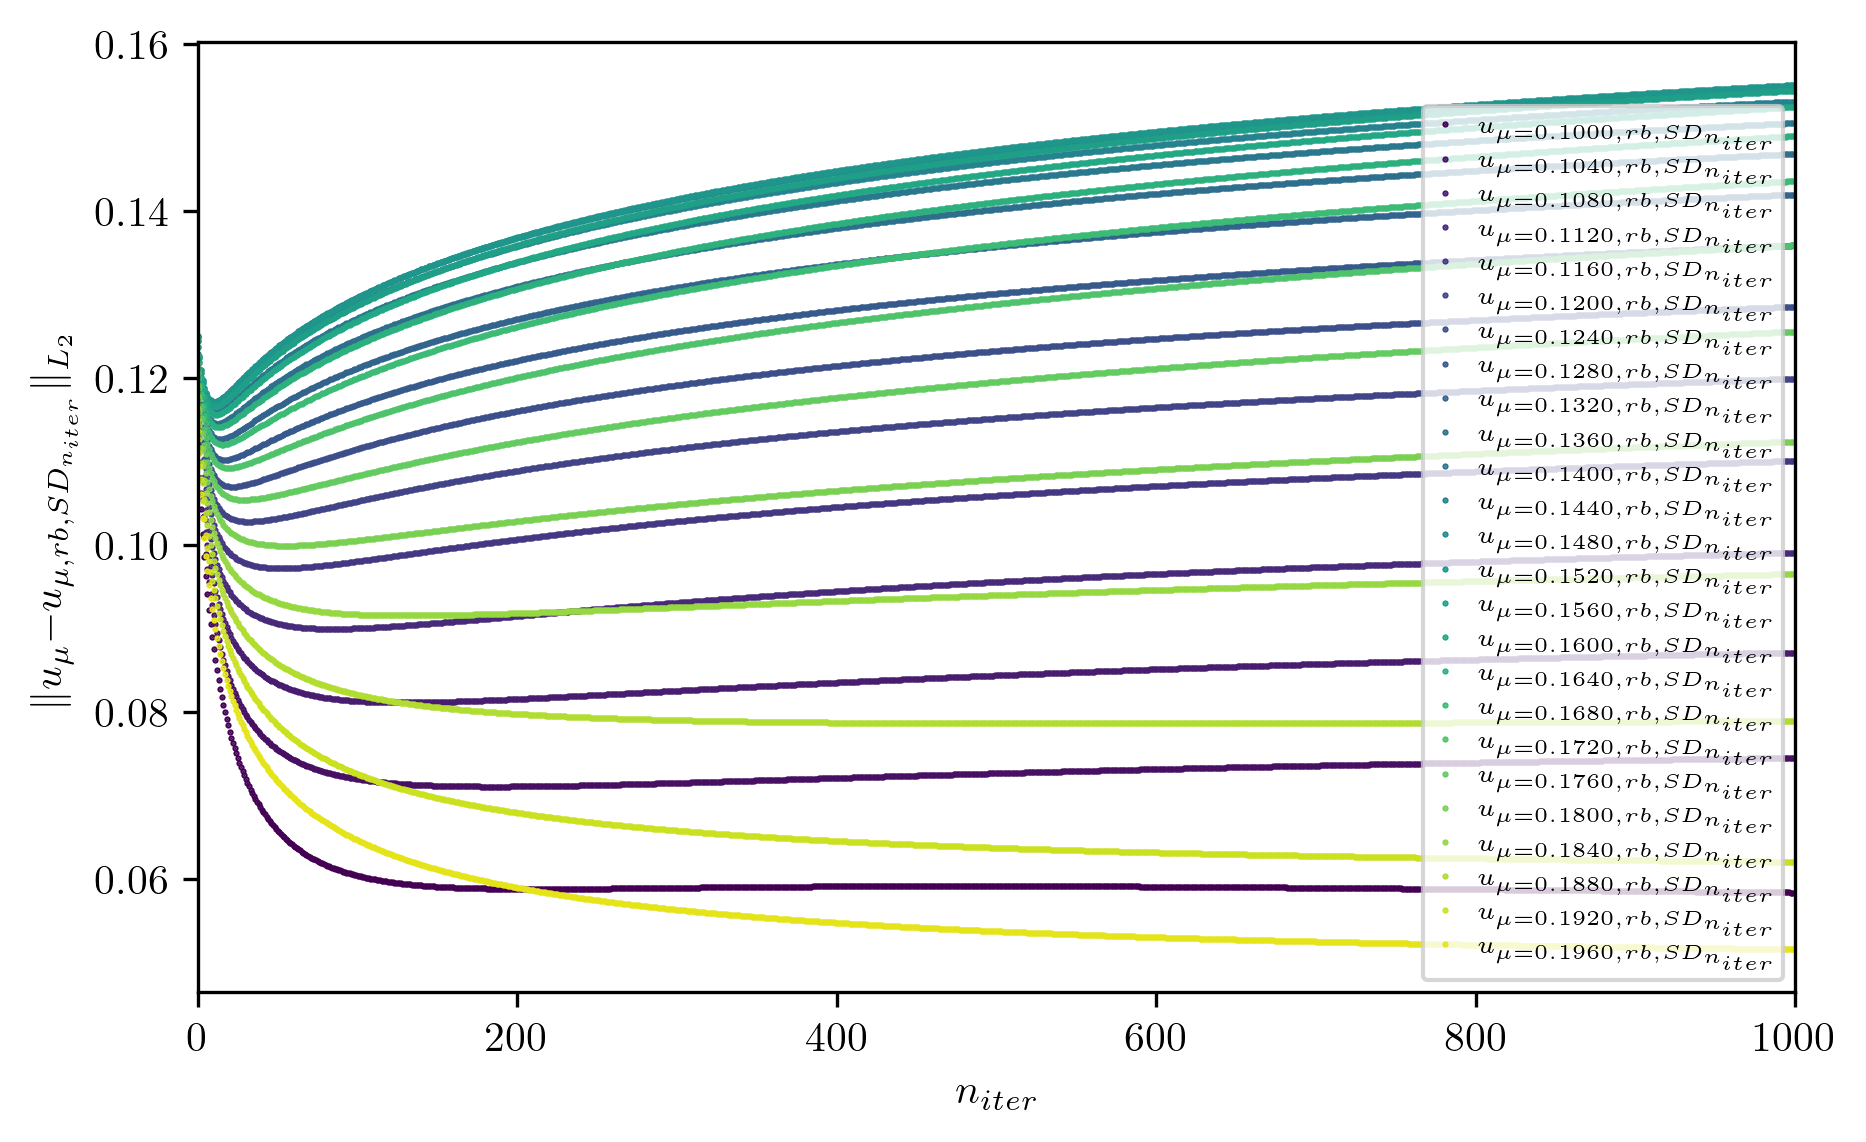

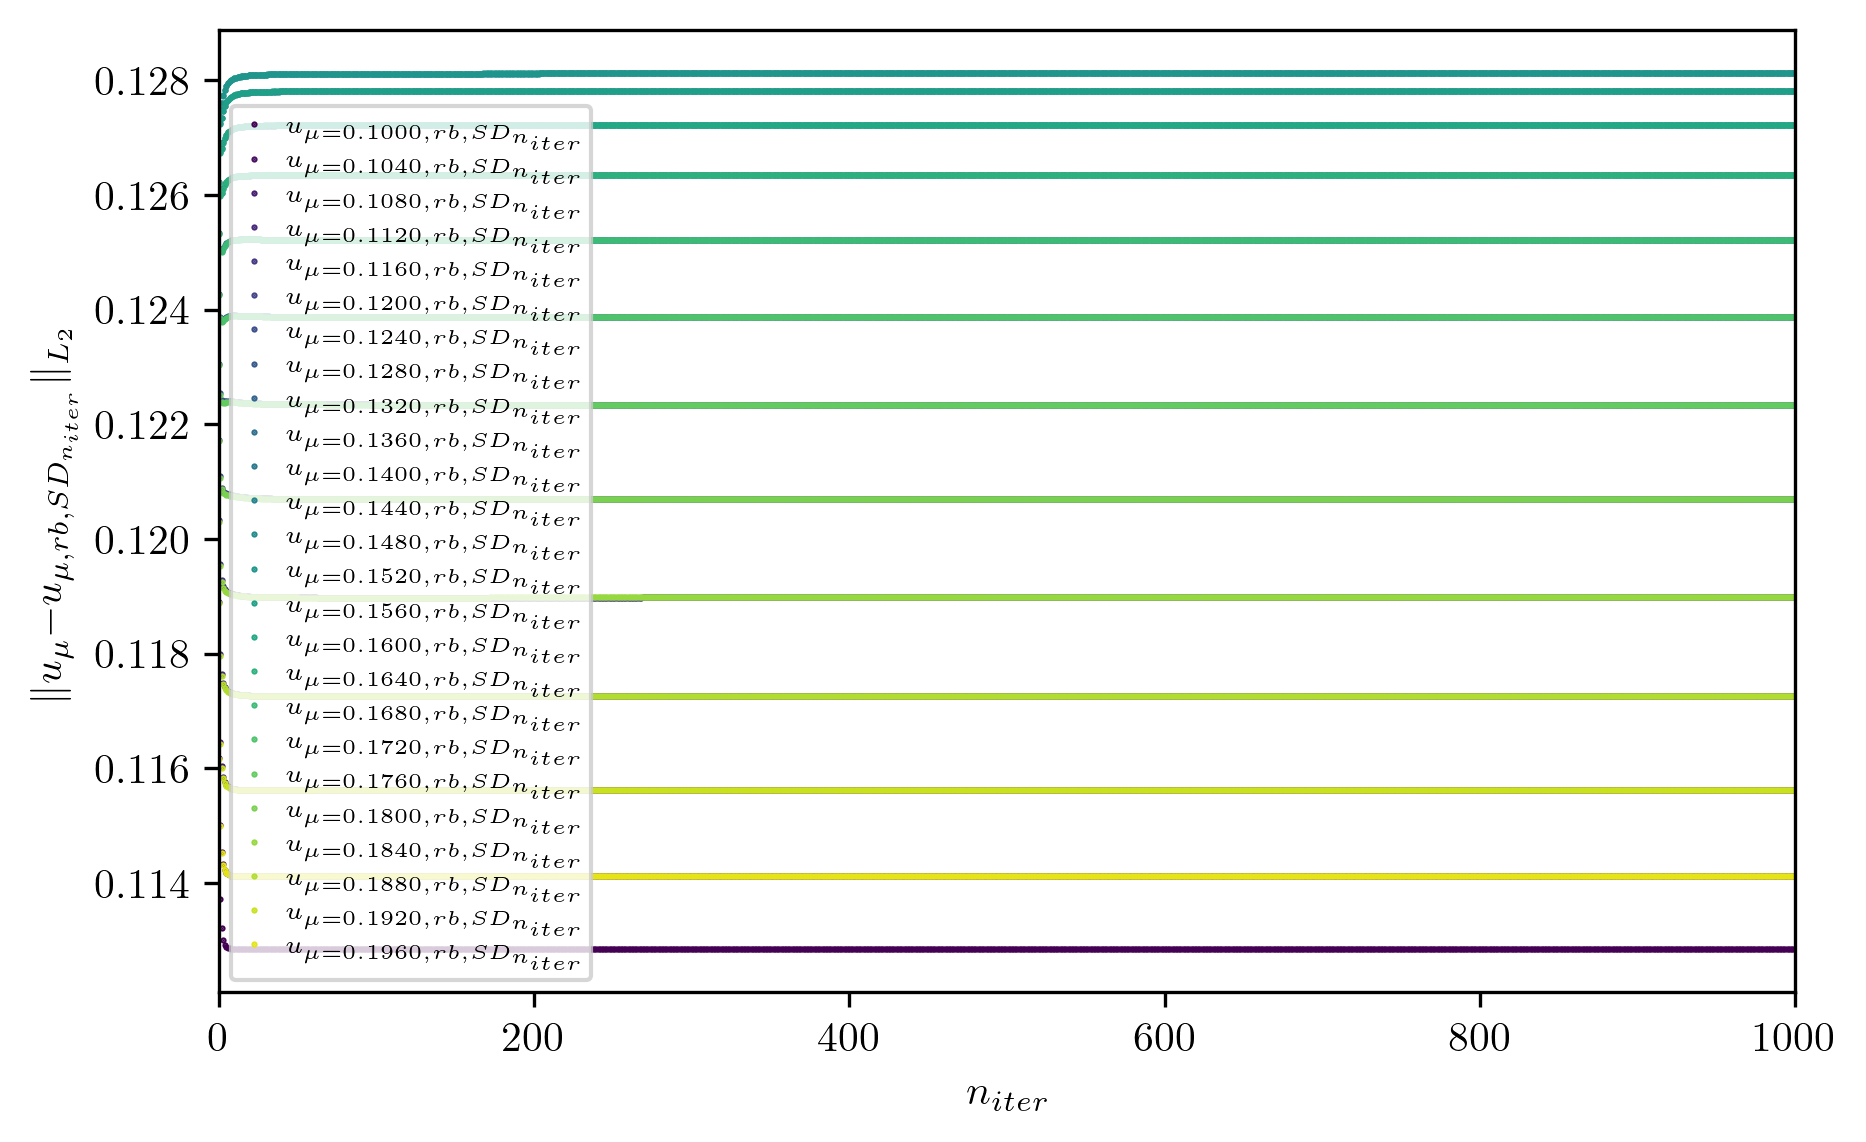

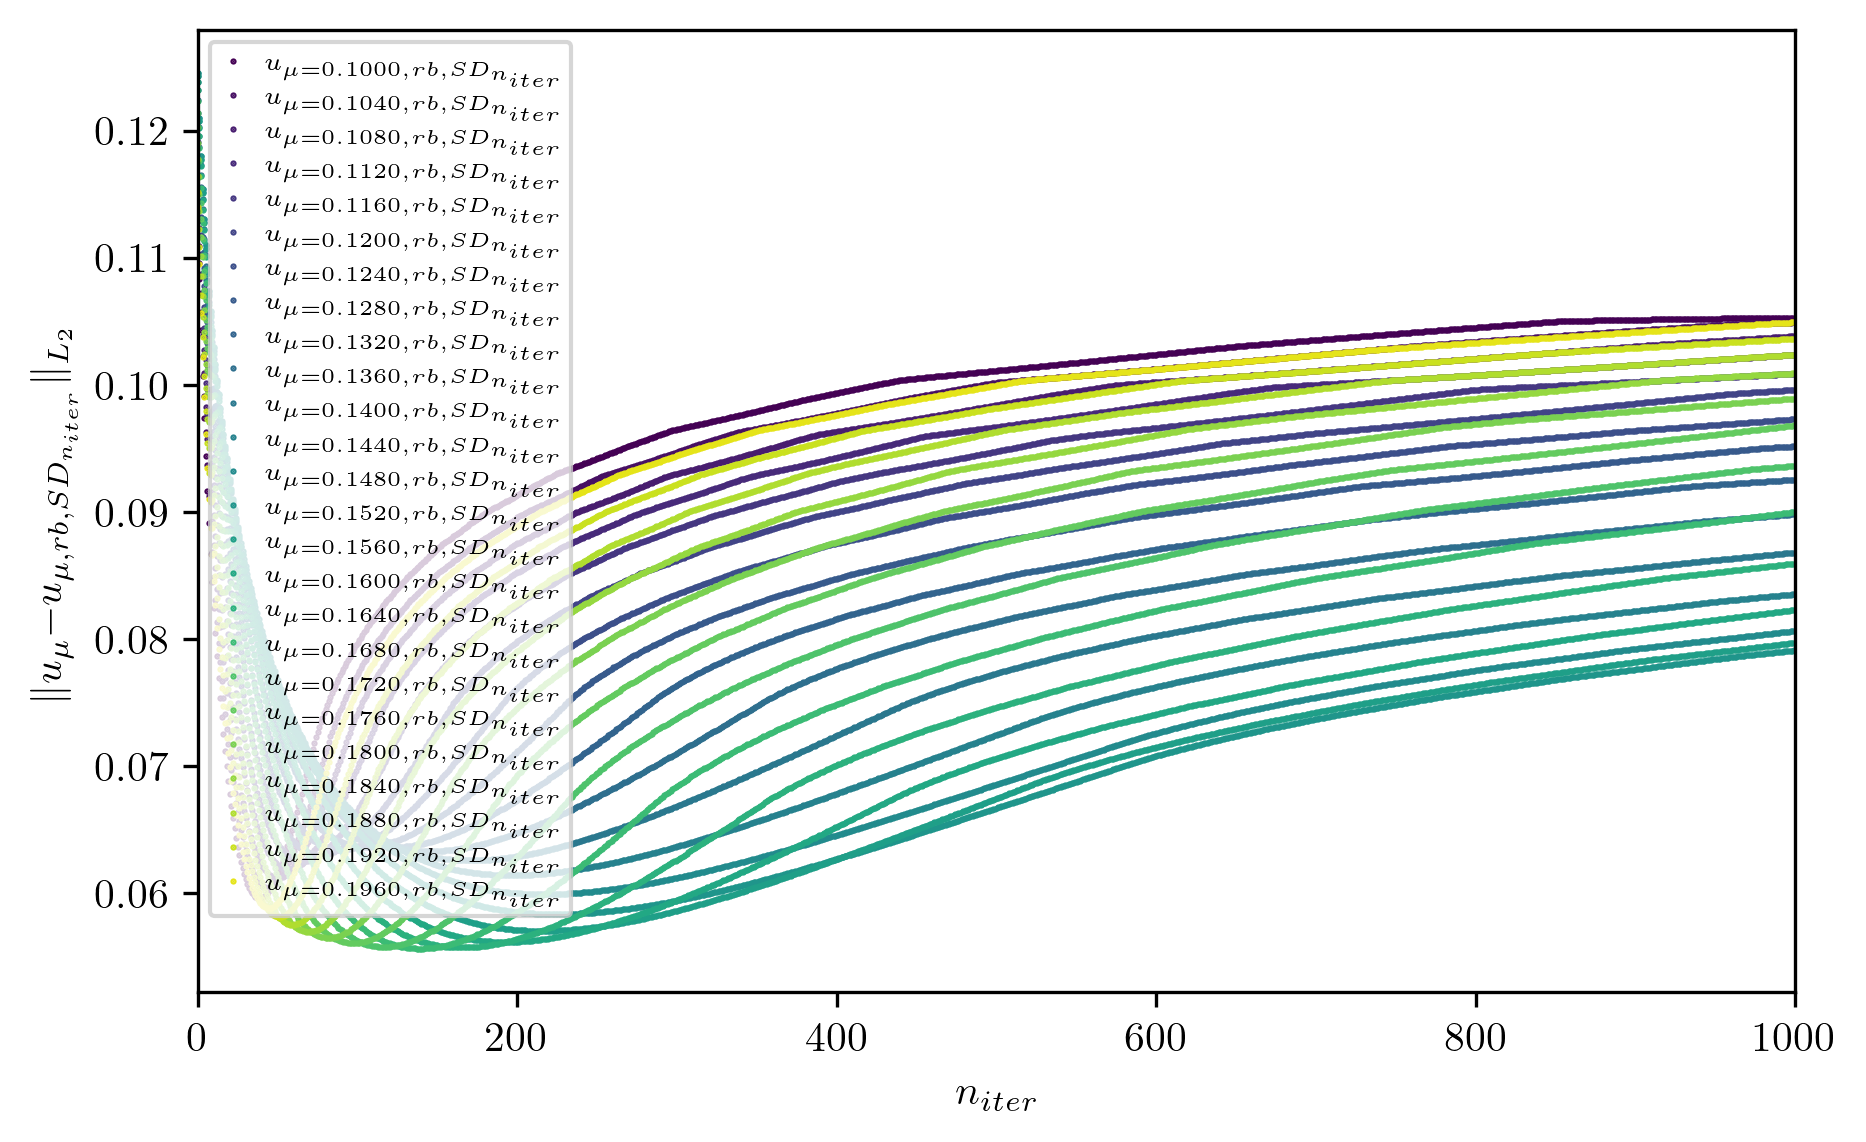

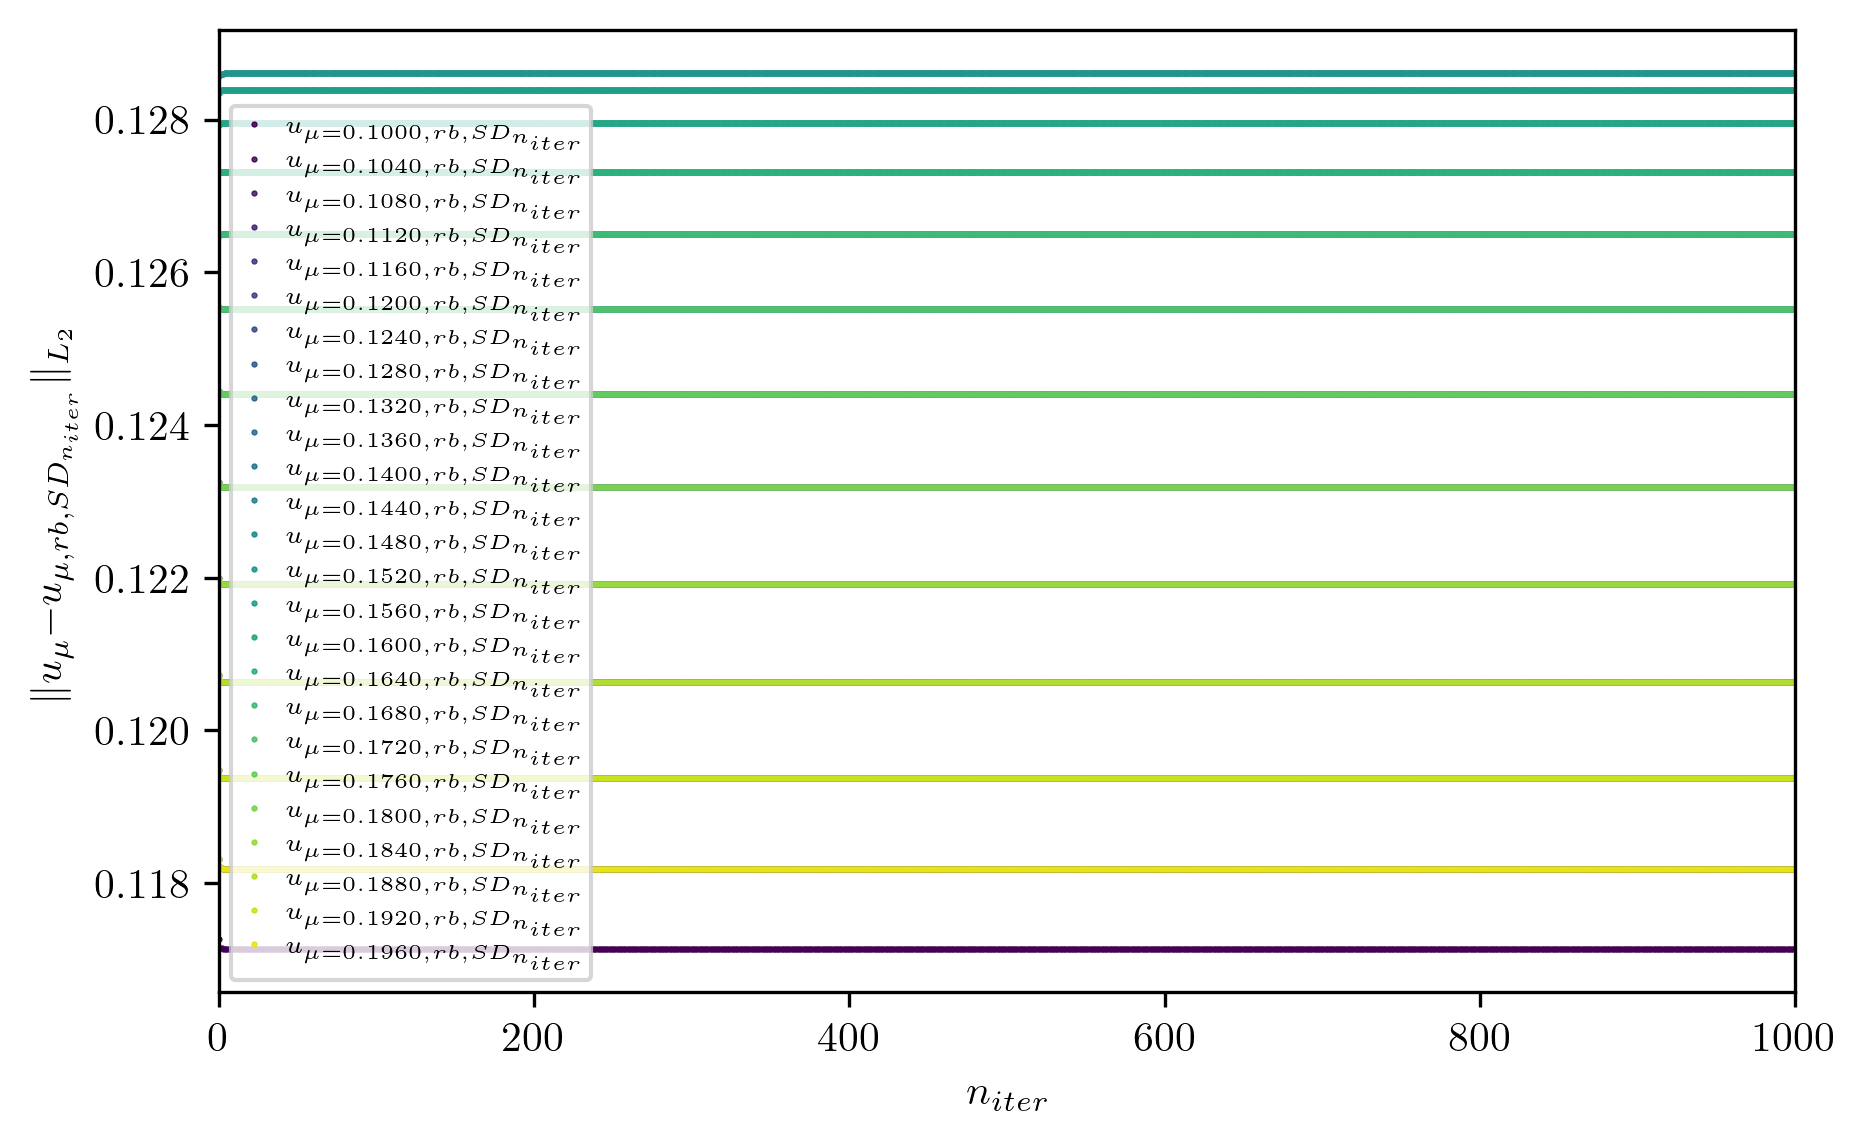

generate snapshots
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.06094444444444445
1 0.030851851851851856
2 0.08079218106995883
3 0.015216049382716052
how does the error converge?


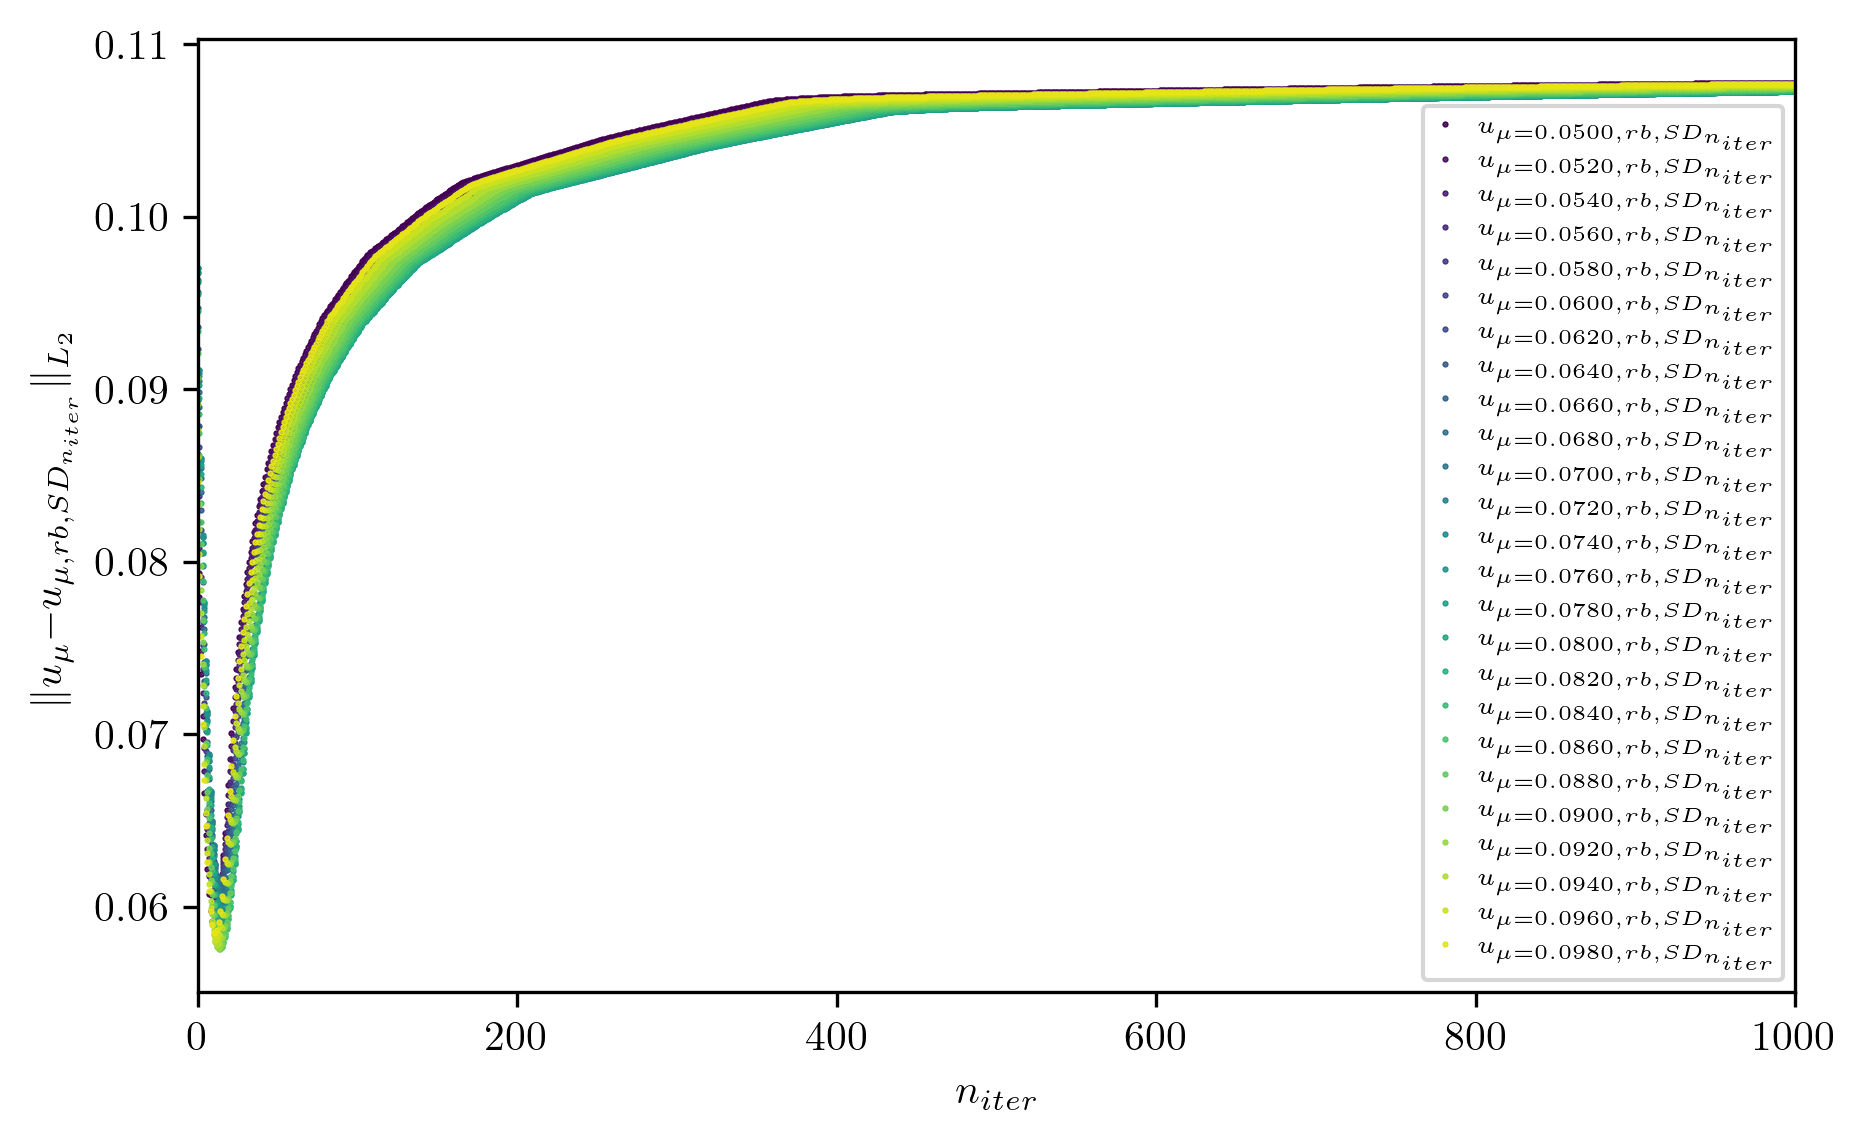

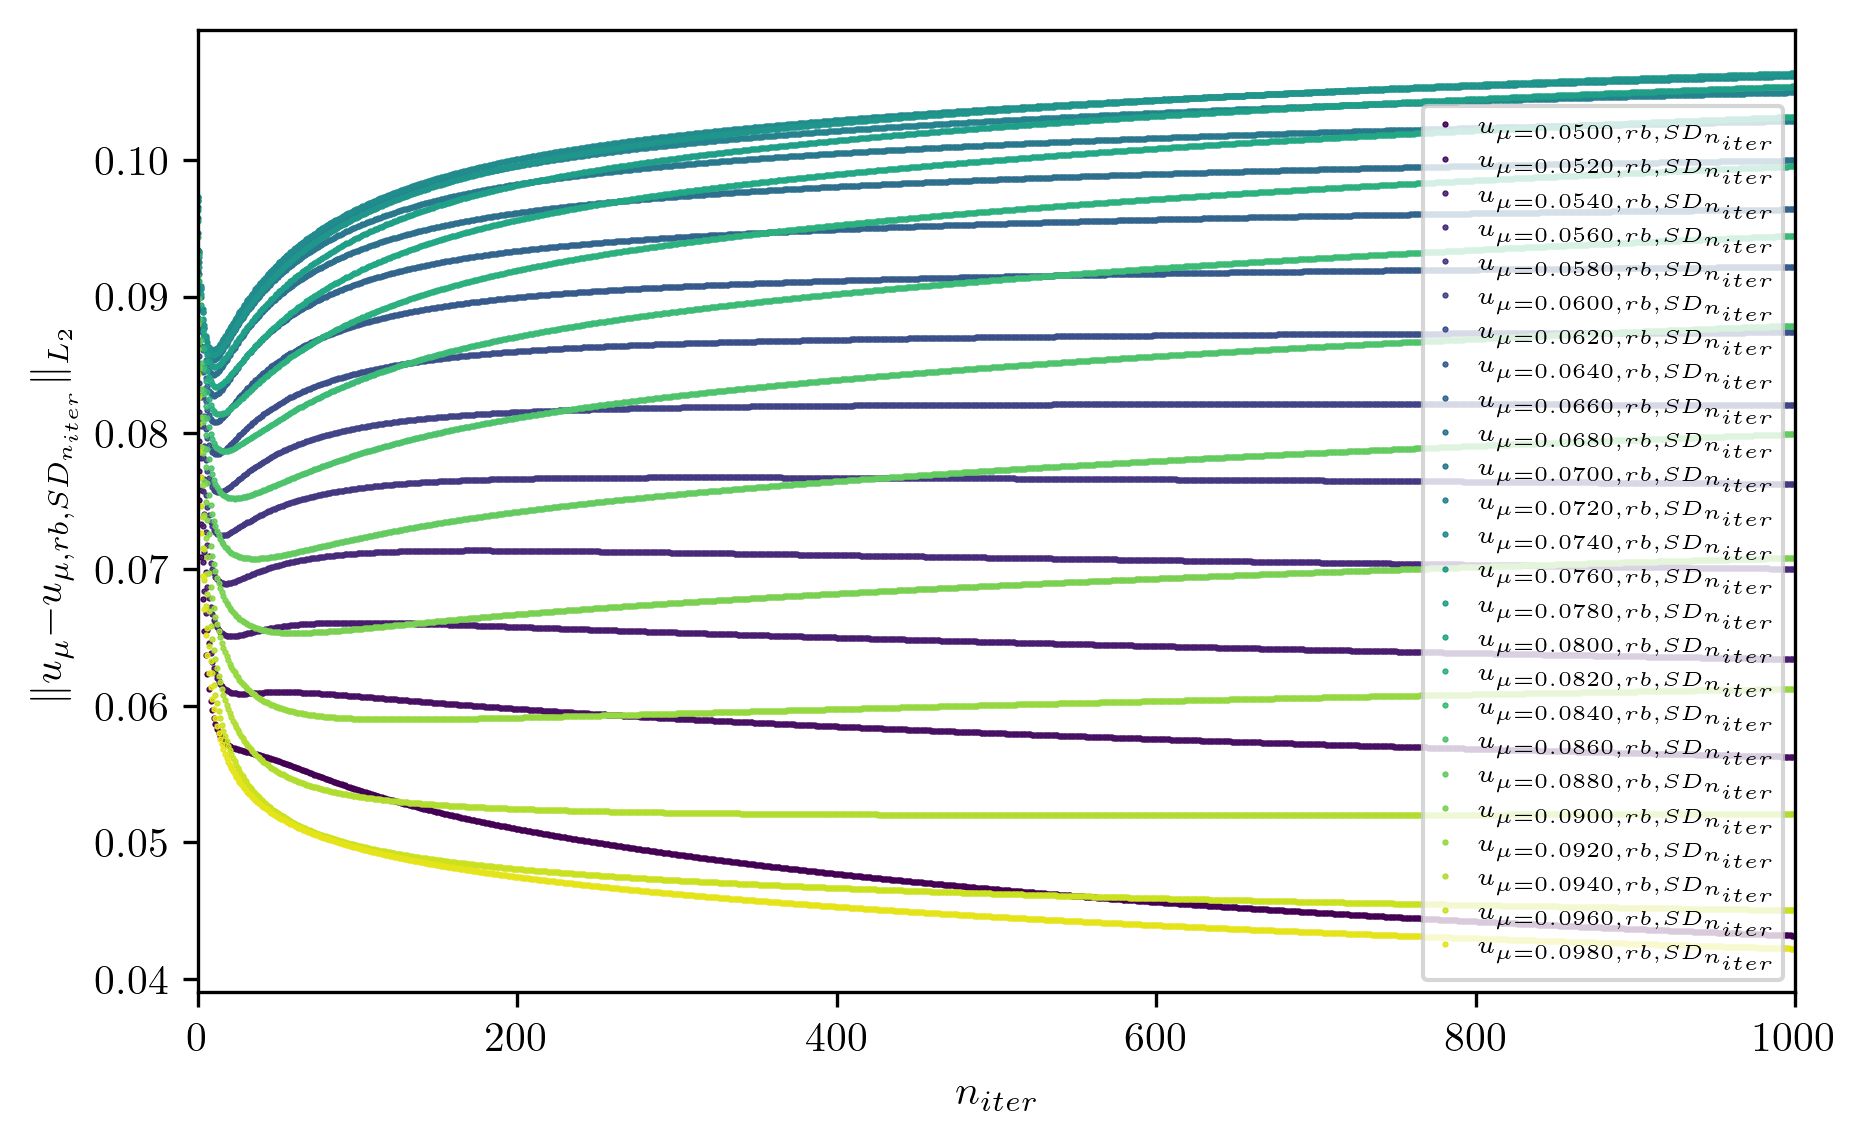

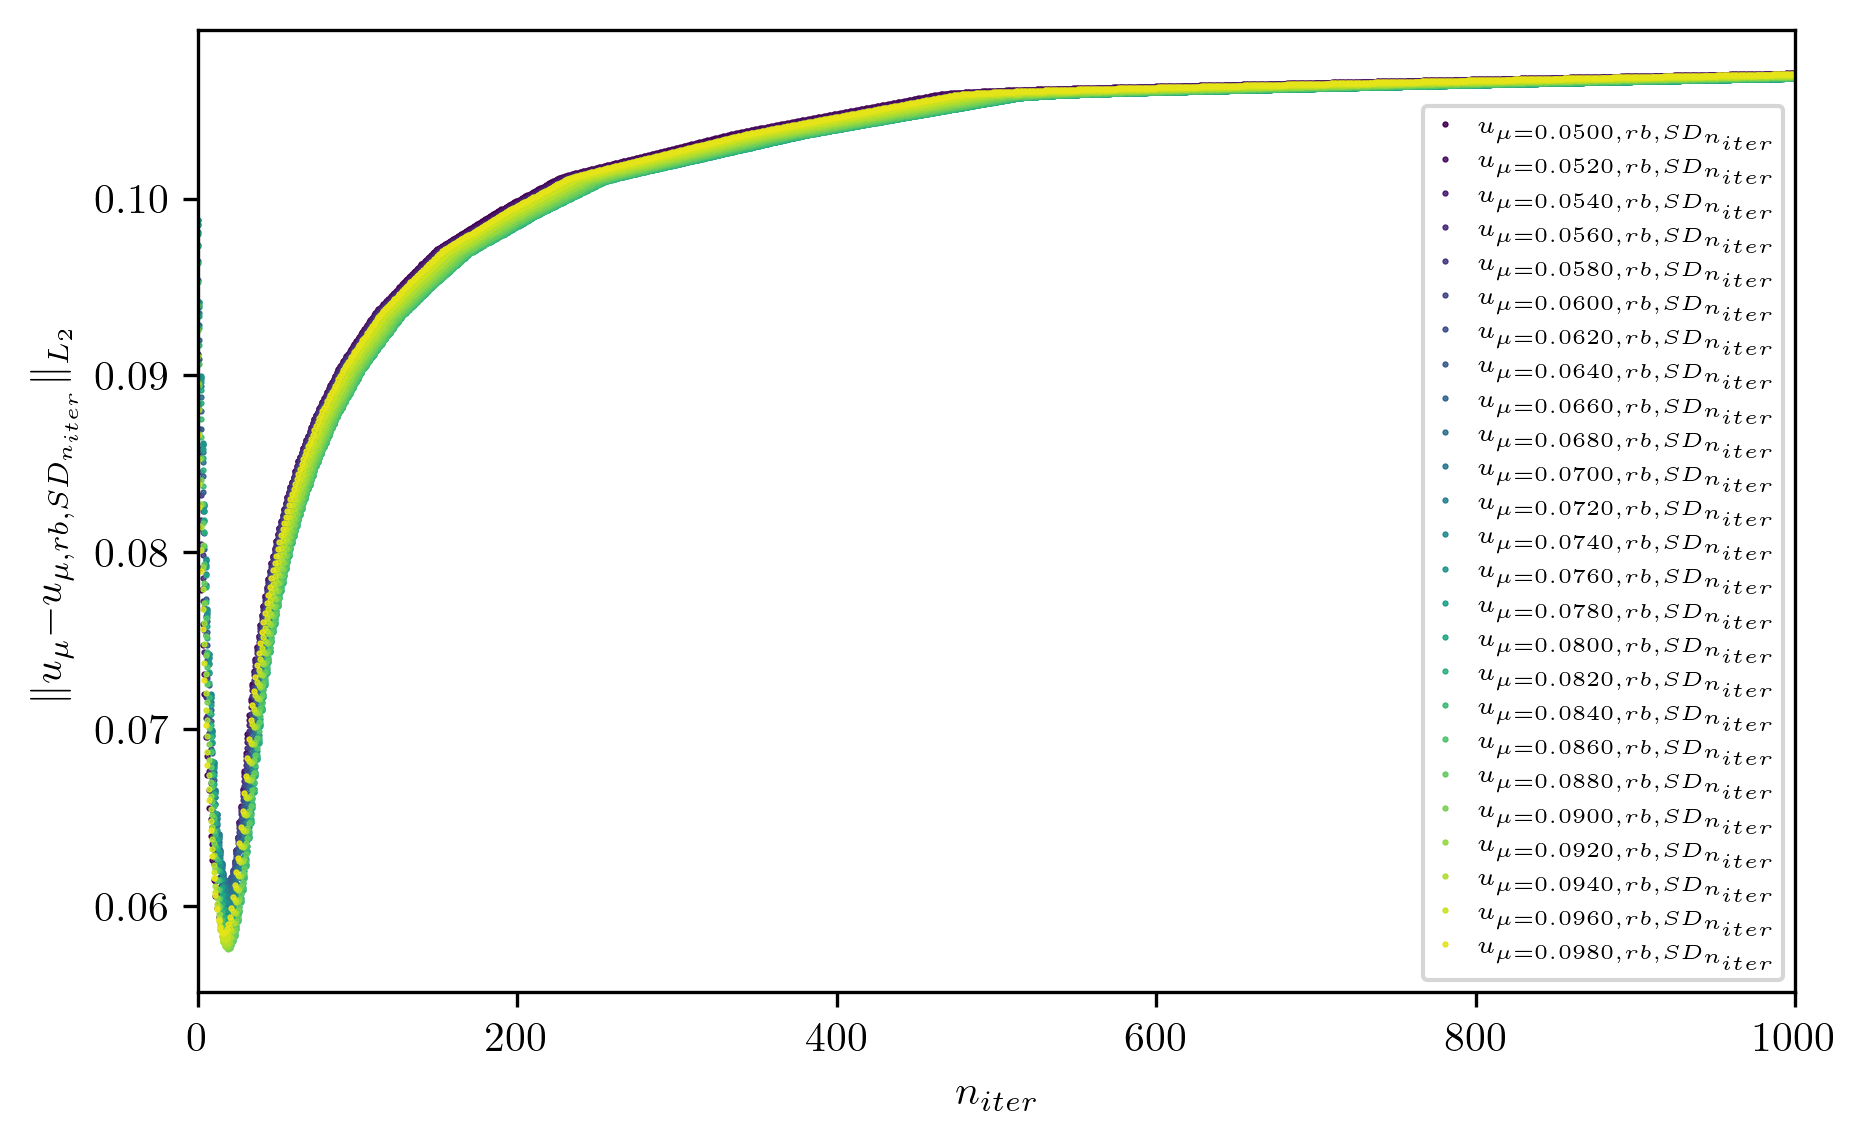

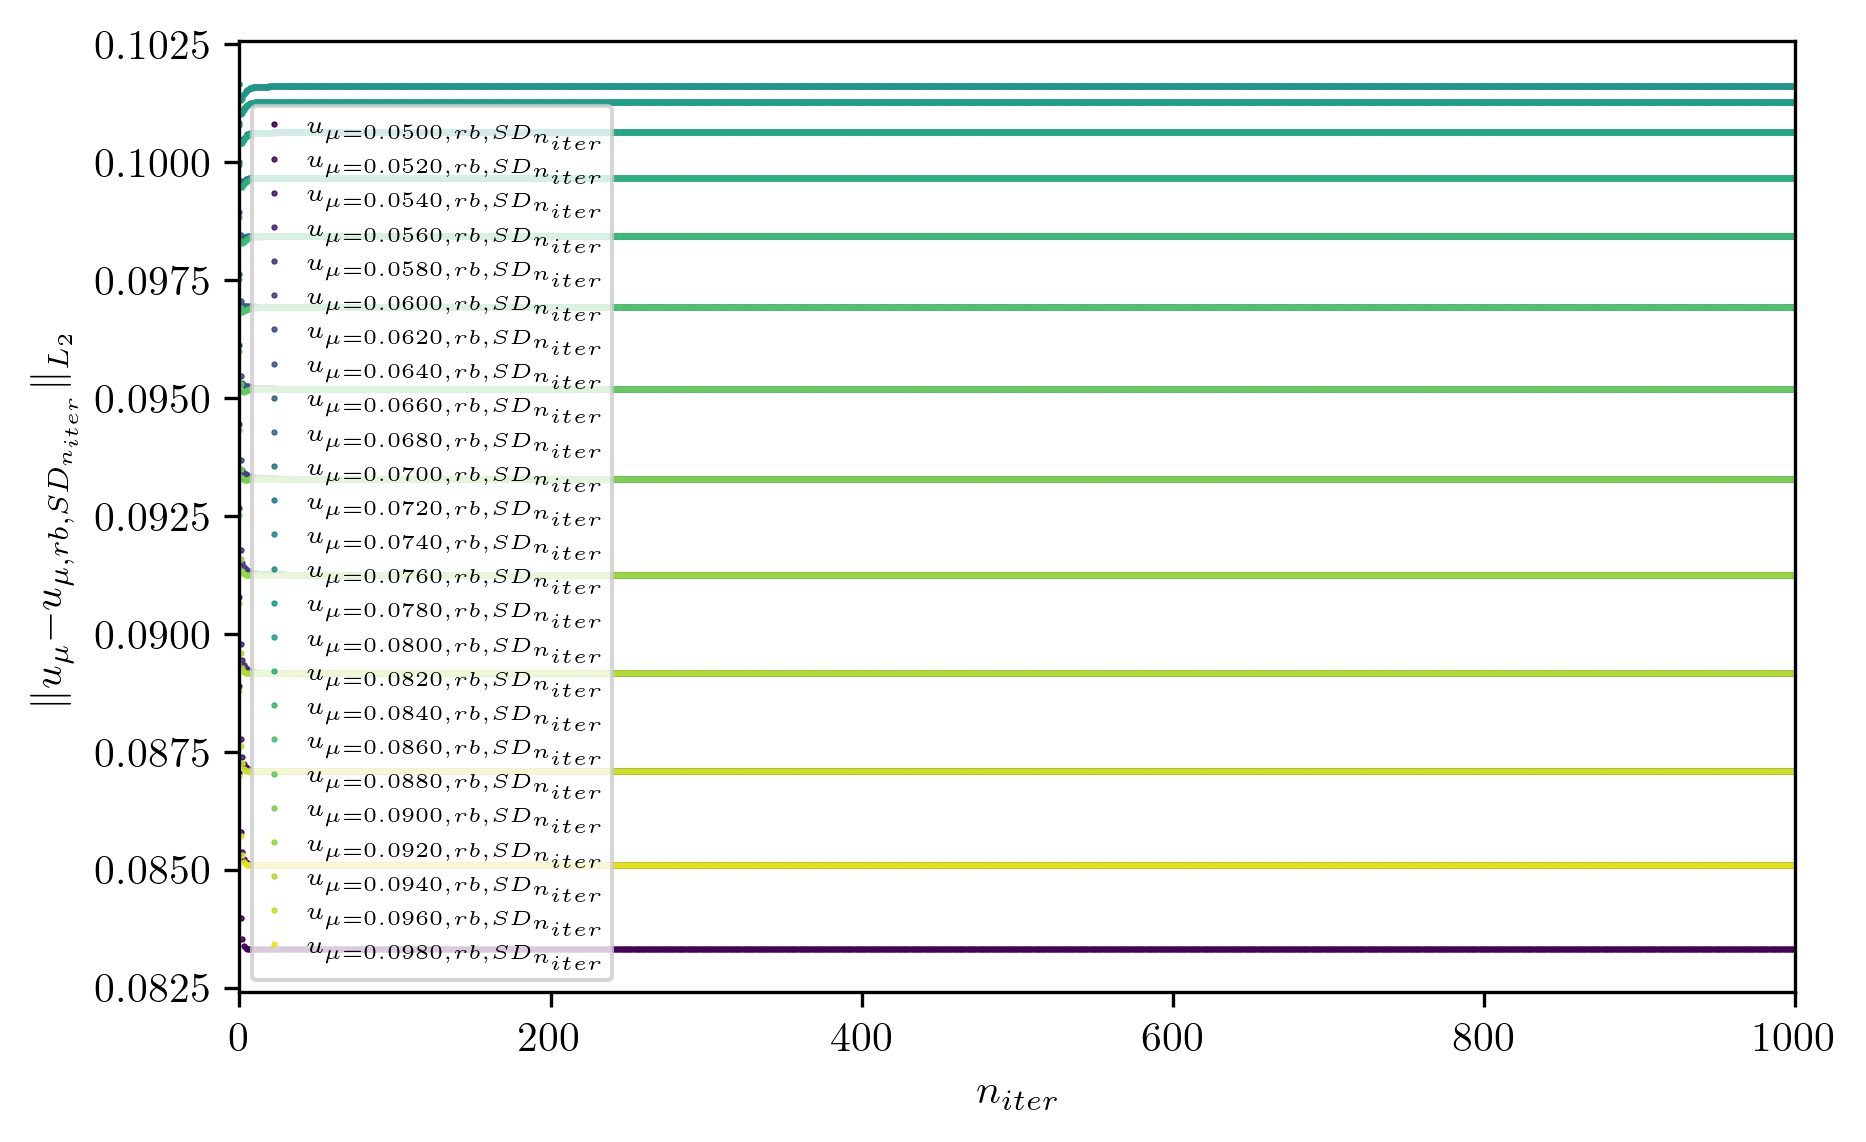

generate snapshots
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.06094444444444445


In [ ]:
case["num_iter"] = 1000
esROMs2 = np.empty((case["n_test"], case["num_iter"], n_sigmaDs, 4))  # i, m, n, case

for case_nr, _rank, _sigma, _c in zip((0, 1, 2, 3), rank_all, sigma_all, c_all):
    print("generate snapshots")
    n_train = _rank
    case["n_train"] = _rank
    case["rank"] = _rank
    case["sigma"] = _sigma
    case["c"] = _c
    shape = case["shape"]

    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, _ = get_predictions(my_sROM, mu_test, **case)

    print("we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot")
    print("SigmaD is varied and we see what happens with the error with the number of iterations in RL")
    #deconvolved = np.ones((*data.shape, num_iter))
    for n, sigmaD in enumerate(sigma_all):
        print(n, sigmaD)
        for i in range(len(mu_test)):
            deconvolved = richardson_lucy(
                x,
                X_test_sROM[i].reshape(shape),
                sigmaD,
                case["num_iter"],
                monitor_convergence=True,
            ).reshape((case["n_x"], case["num_iter"]))

            esROMs2[i, :, n, case_nr] = L2_error_rw(deconvolved, X_test[i, :, None], axis=0)

    print("how does the error converge?")
    for k in range(4):
        __sigma = sigmaDs[k]
        fig, ax = plt.subplots(figsize=(plot_width_in*2, plot_width_in*2/1.61803398875))
        for j in range(case["n_test"]):
            plt.plot(esROMs2[j, :, k, case_nr], marker=".", ms=1, lw=0, 
                     color=cmap(j/case["n_test"]), label=r"$u_{\mu="+"{:.4f}".format(mu_test[j, 0])+",rb,SD_{n_{iter}}}$")
        plt.legend()
        plt.xlim(0, len(esROMs2[j, :, k, case_nr]))
        plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_{iter}}}}\|_{L_2}$")
        plt.xlabel(r"$n_{iter}$")
        plt.show()